In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statistics as st

In [2]:
df_cluster = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv')
df_cluster.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score,VT Malicious,VT Suspicious,VT Harmless,VT NoData Available
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,False,False,False,False,False,0,0,0,1,1
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,False,False,False,True,False,55,0,0,1,1
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,False,False,False,False,False,0,1,0,0,1
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,False,False,False,True,False,55,0,0,1,1
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,False,False,True,True,False,91,0,0,1,1


In [91]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2118 entries, 0 to 2117
Data columns (total 53 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2118 non-null   float64
 1   Same Landing Domain                          2118 non-null   int64  
 2   Has Bank Related Keywords                    2118 non-null   int64  
 3   Has Crypto Related Keywords                  2118 non-null   int64  
 4   Has Card Related Keywords                    2118 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2118 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2118 non-null   int64  
 7   Avg_External_Links_Len                       2118 non-null   float64
 8   Stdv_External_Links_Len                      2118 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2118 non-null   float64
 10  

In [3]:
# df_feature = pd.read_csv('../Data/final_feature_data.csv')
df_feature = df_cluster.copy()
df_feature.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score,VT Malicious,VT Suspicious,VT Harmless,VT NoData Available
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,False,False,False,False,False,0,0,0,1,1
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,False,False,False,True,False,55,0,0,1,1
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,False,False,False,False,False,0,1,0,0,1
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,False,False,False,True,False,55,0,0,1,1
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,False,False,True,True,False,91,0,0,1,1


In [4]:
df_feature['Status Code'].value_counts()

Status Code
 200    1617
-1       420
 404      47
 403      13
 503       4
 500       4
 520       3
 401       2
 530       2
 521       2
 502       1
 418       1
 429       1
 423       1
Name: count, dtype: int64

In [5]:
df_feature['K-means Label'] = df_cluster['K-means Label']
df_feature['KMedoids Label'] = df_cluster['KMedoids Label']
df_feature['Hierarchical Label'] = df_cluster['Hierarchical Label']
df_feature['DBSCAN Label'] = df_cluster['DBSCAN Label']
df_feature['GMM Label'] = df_cluster['GMM Label']
df_feature['Majority Voting Label'] = df_cluster['Majority Voting Label']

df_feature.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score,VT Malicious,VT Suspicious,VT Harmless,VT NoData Available
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,False,False,False,False,False,0,0,0,1,1
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,False,False,False,True,False,55,0,0,1,1
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,False,False,False,False,False,0,1,0,0,1
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,False,False,False,True,False,55,0,0,1,1
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,False,False,True,True,False,91,0,0,1,1


In [6]:
live_url_IPQS_analysis = pd.read_csv("../Data/all_active_URLS_IPQS_analysis.csv")
live_url_IPQS_analysis

,url,unsafe,status_code,parking,spamming,malware,phishing,suspicious,adult,risk_score
0,napavalleytoukraine.org,False,301,False,False,False,False,False,False,0
1,cannabiswithukraine.org,False,200,False,False,False,False,True,False,90
2,givetoukrainetoday.com,False,200,False,False,False,False,True,False,55
3,beforukraine.com,False,200,True,False,False,False,True,False,90
4,ukrainianaid.co.uk,False,200,True,False,False,False,True,False,99
...,...,...,...,...,...,...,...,...,...,...
2875,save-ukraine.life,False,200,False,False,False,False,False,False,40
2876,ukraineaid.online,False,200,False,False,False,False,False,False,72
2877,haarlem4ukraine.nl,False,200,False,False,False,False,False,False,0
2878,ukraine-willkommen.de,False,200,False,False,False,False,False,False,0


In [7]:
data_ = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv')
data_.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,IPQS Spamming,IPQS malware,IPQS Phishing,IPQS Suspicious,IPQS Adult,IPQS Risk Score,VT Malicious,VT Suspicious,VT Harmless,VT NoData Available
0,86.53,1,0,0,0,7,5,50.80,10.26,0.0,...,False,False,False,False,False,0,0,0,1,1
1,123.73,1,0,0,0,15,2,75.50,32.50,0.0,...,False,False,False,True,False,55,0,0,1,1
2,96.91,1,0,0,0,2,3,43.00,5.10,0.0,...,False,False,False,False,False,0,1,0,0,1
3,1170.81,1,0,0,0,1,14,45.43,24.74,0.0,...,False,False,False,True,False,55,0,0,1,1
4,47.44,1,0,0,0,25,19,29.11,17.09,0.0,...,False,False,True,True,False,91,0,0,1,1


In [8]:
df_feature['IPQS_Flag'] = data_['IPQS_Flag']

In [9]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2118 entries, 0 to 2117
Data columns (total 53 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2118 non-null   float64
 1   Same Landing Domain                          2118 non-null   int64  
 2   Has Bank Related Keywords                    2118 non-null   int64  
 3   Has Crypto Related Keywords                  2118 non-null   int64  
 4   Has Card Related Keywords                    2118 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2118 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2118 non-null   int64  
 7   Avg_External_Links_Len                       2118 non-null   float64
 8   Stdv_External_Links_Len                      2118 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2118 non-null   float64
 10  

In [10]:
df_feature.to_csv('../Data/final_full_website_data_with_features_and_cluster.csv', index=None)

In [11]:
df = pd.read_csv('../Data/Live_Websites_Page_Count_5.csv')
df.head()

,URL,Page Size In Byte,Status Code,Same Domain Unique Page Count,Other Website Unique Link Count,Other Website Uniques Links,Cluster Label
0,https://www.1001minutesforukraine.com,85077,200,7,5,['https://www.facebook.com/1001-Minutes-for-Uk...,0
1,https://www.1to1ukrainemuseums.org,124701,200,15,2,['https://padlet.com/linda22/uk9hqc1ftu82xcwy'...,0
2,https://www.1violettepourlukraine.fr,96554,200,2,3,['https://www.facebook.com/UneViolettePourlUkr...,2
3,https://www.33lettersforukraine.com,1170806,200,1,14,"['https://www.instagram.com/36daysoftype', 'ht...",0
4,https://www.411ukraine.com,0,-1,0,0,NaN,2


In [12]:
len(set(df_feature['Searched_URL']).intersection(set(df['URL'])))

2118

In [13]:
df['Status Code'].to_list().count(200)

2118

In [14]:
df = df[df['Status Code']==200]
df.index = range(0,len(df))
len(df)

2118

In [15]:
for i in range(len(df)):
    if df['URL'][i]!=df_feature['Searched_URL'][i]:
        print('Alert')


In [16]:
df['Cluster Label'] = df_cluster['Majority Voting Label']

In [17]:
df

,URL,Page Size In Byte,Status Code,Same Domain Unique Page Count,Other Website Unique Link Count,Other Website Uniques Links,Cluster Label
0,https://www.1001minutesforukraine.com,85077,200,7,5,['https://www.facebook.com/1001-Minutes-for-Uk...,0
1,https://www.1to1ukrainemuseums.org,124701,200,15,2,['https://padlet.com/linda22/uk9hqc1ftu82xcwy'...,0
2,https://www.1violettepourlukraine.fr,96554,200,2,3,['https://www.facebook.com/UneViolettePourlUkr...,0
3,https://www.33lettersforukraine.com,1170806,200,1,14,"['https://www.instagram.com/36daysoftype', 'ht...",0
4,https://www.4myukraine.com,47441,200,25,19,"['https://www.facebook.com/4myukraine', 'https...",2
...,...,...,...,...,...,...,...
2113,https://www.yssukraine.com,76147,200,22,4,['https://youtube.com/channel/UCZ0OloflVnraDFb...,0
2114,https://www.zbroimyukraine.pl,363046,200,10,13,['https://www.youtube.com/channel/UCwE0BTL9pFW...,0
2115,https://www.zuerichhilftderukraine.ch,479368,200,10,4,['https://www.instagram.com/zuerich_hilft_der_...,0
2116,https://www.zugang-b-ukraine.org,304139,200,1,0,[],0


In [18]:
live_set = {}
for i in range(len(df)):
    if df['Status Code'][i]==200:
        live_set[df['URL'][i]] = [df['Same Domain Unique Page Count'][i],df['Cluster Label'][i]]

live_set

{'https://www.1001minutesforukraine.com': [7, 0],
 'https://www.1to1ukrainemuseums.org': [15, 0],
 'https://www.1violettepourlukraine.fr': [2, 0],
 'https://www.33lettersforukraine.com': [1, 0],
 'https://www.4myukraine.com': [25, 2],
 'https://www.4ukraine.ca': [27, 0],
 'https://www.4ukraine.co': [2, 2],
 'https://www.4ukraine.cz': [1, 2],
 'https://www.4ukraine.eu': [1, 2],
 'https://www.4ukraine.net': [14, 0],
 'https://www.4ukraine.org.uk': [16, 0],
 'https://www.4ukraine.pl': [1, 0],
 'https://www.4ukrainians.com': [7, 0],
 'https://www.518ukrainians.com': [7, 0],
 'https://www.a4-ukraine.com': [7, 0],
 'https://www.aboutukraine.org': [1, 1],
 'https://www.about-ukraine.org': [1, 0],
 'https://www.absolutejobsforukraine.be': [3, 2],
 'https://www.act-for-ukraine.co': [1, 2],
 'https://www.actinukrainenow.com': [2, 0],
 'https://www.actinukrainenow.org': [20, 0],
 'https://www.action4ukraine.org': [2, 2],
 'https://www.actions-fondations-ukraine.org': [1, 1],
 'https://www.action-

In [19]:
len(live_set)

2118

In [20]:
cluster_1 = df.loc[df['Cluster Label']==0]
cluster_2 = df.loc[df['Cluster Label']==1]
cluster_3 = df.loc[df['Cluster Label']==2]

In [21]:
def cluster_wise_status_code(entry,name):
    codes = np.unique(df['Status Code'])
    cnt = {'Cluster': name}
    for i in codes:
        cnt[i] = entry.to_list().count(i)
    
    return pd.DataFrame([cnt])

In [22]:
status_codes_for_individual_cluster = cluster_wise_status_code(cluster_1['Status Code'],'cluster_1')
status_codes_for_individual_cluster = pd.concat([status_codes_for_individual_cluster,cluster_wise_status_code(cluster_2['Status Code'],'cluster_2')], axis=0,ignore_index=True)
status_codes_for_individual_cluster = pd.concat([status_codes_for_individual_cluster,cluster_wise_status_code(cluster_3['Status Code'],'cluster_3')], axis=0,ignore_index=True)
status_codes_for_individual_cluster

,Cluster,200
0,cluster_1,1149
1,cluster_2,388
2,cluster_3,581


In [23]:
def Page_Analysis(entry,name):
  stats = {
    'Cluster': name,
    'Mean': np.round((st.mean(entry)),2),
    'Median': np.round((st.median(entry)),2),
    'Mode': np.round((st.mode(entry)),2),
    'STD': np.round((st.stdev(entry)),2),
    'MAX':np.round((max(entry)),2),
    'MIN':np.round((min(entry)),2)
  }
  stats['Highest Fequency'] = entry.to_list().count(stats['Mode'])
  return pd.DataFrame([stats])

In [24]:
page_sizes = Page_Analysis(cluster_1['Page Size In Byte'],'cluster_1')
page_sizes = pd.concat([page_sizes,Page_Analysis(cluster_2['Page Size In Byte'],'cluster_2')], axis=0,ignore_index=True)
page_sizes = pd.concat([page_sizes,Page_Analysis(cluster_3['Page Size In Byte'],'cluster_3')], axis=0,ignore_index=True)
page_sizes = pd.concat([page_sizes,Page_Analysis(df['Page Size In Byte'],'full')], axis=0,ignore_index=True)
page_sizes

,Cluster,Mean,Median,Mode,STD,MAX,MIN,Highest Fequency
0,cluster_1,263711.59,147470.0,175472,305352.84,2808144,114,5
1,cluster_2,2574.36,989.0,114,6198.06,56385,0,116
2,cluster_3,40685.59,34461.0,17297,61470.56,1257089,244,6
3,full,154693.95,65840.0,114,256638.21,2808144,0,120


In [25]:
page_cnt = Page_Analysis(cluster_1['Same Domain Unique Page Count'],'cluster_1')
page_cnt = pd.concat([page_cnt,Page_Analysis(cluster_2['Same Domain Unique Page Count'],'cluster_2')], axis=0,ignore_index=True)
page_cnt = pd.concat([page_cnt,Page_Analysis(cluster_3['Same Domain Unique Page Count'],'cluster_3')], axis=0,ignore_index=True)
page_cnt

,Cluster,Mean,Median,Mode,STD,MAX,MIN,Highest Fequency
0,cluster_1,15.74,8.0,1,29.92,469,1,152
1,cluster_2,1.63,1.0,1,2.99,31,1,352
2,cluster_3,11.85,4.0,1,38.35,501,1,174


In [26]:
other_link_cnt = Page_Analysis(cluster_1['Other Website Unique Link Count'],'cluster_1')
other_link_cnt = pd.concat([other_link_cnt,Page_Analysis(cluster_2['Other Website Unique Link Count'],'cluster_2')], axis=0,ignore_index=True)
other_link_cnt = pd.concat([other_link_cnt,Page_Analysis(cluster_3['Other Website Unique Link Count'],'cluster_3')], axis=0,ignore_index=True)
other_link_cnt

,Cluster,Mean,Median,Mode,STD,MAX,MIN,Highest Fequency
0,cluster_1,4.80,3.0,1,8.57,139,0,174
1,cluster_2,0.00,0.0,0,0.00,0,0,388
2,cluster_3,4.57,2.0,1,6.75,79,0,189


In [27]:
def page_cnt_wthin_ranges(entry,name):

    ranges = {'Cluster':name,'0 page':0,'1 page':0,'2-3 pages':0, '4-5 pages':0,'6-10 pages':0,'> 10 pages':0}
    for i in entry:
        if i==0:
            ranges['0 page'] += 1
        elif i==1:
            ranges['1 page'] += 1
        elif i<4:
            ranges['2-3 pages'] += 1
        elif i<6:
            ranges['4-5 pages'] += 1
        elif i<11:
            ranges['6-10 pages'] += 1
        else:
            ranges['> 10 pages'] += 1
    
    return pd.DataFrame([ranges])

In [28]:
page_cnt_ranges = page_cnt_wthin_ranges(cluster_1['Same Domain Unique Page Count'],'cluster_1')
page_cnt_ranges = pd.concat([page_cnt_ranges,page_cnt_wthin_ranges(cluster_2['Same Domain Unique Page Count'],'cluster_2')], axis=0,ignore_index=True)
page_cnt_ranges = pd.concat([page_cnt_ranges,page_cnt_wthin_ranges(cluster_3['Same Domain Unique Page Count'],'cluster_3')], axis=0,ignore_index=True)
# page_cnt_ranges = pd.concat([page_cnt_ranges,page_cnt_wthin_ranges(df['Same Domain Unique Page Count'],'cluster_3')], axis=0,ignore_index=True)
page_cnt_ranges

,Cluster,0 page,1 page,2-3 pages,4-5 pages,6-10 pages,> 10 pages
0,cluster_1,0,152,161,105,275,456
1,cluster_2,0,352,14,6,6,10
2,cluster_3,0,174,109,57,87,154


In [29]:
other_link_cnt_ranges = page_cnt_wthin_ranges(cluster_1['Other Website Unique Link Count'],'cluster_1')
other_link_cnt_ranges = pd.concat([other_link_cnt_ranges,page_cnt_wthin_ranges(cluster_2['Other Website Unique Link Count'],'cluster_2')], axis=0,ignore_index=True)
other_link_cnt_ranges = pd.concat([other_link_cnt_ranges,page_cnt_wthin_ranges(cluster_3['Other Website Unique Link Count'],'cluster_3')], axis=0,ignore_index=True)
other_link_cnt_ranges

,Cluster,0 page,1 page,2-3 pages,4-5 pages,6-10 pages,> 10 pages
0,cluster_1,172,174,310,212,182,99
1,cluster_2,388,0,0,0,0,0
2,cluster_3,9,189,165,79,88,51


In [30]:
print('websites with single page but contains more than 10 unique links of other websites')
print("cluster 1 count:",len(cluster_1.loc[(cluster_1['Same Domain Unique Page Count']==1) & (cluster_1['Other Website Unique Link Count']>=10)]))
print("cluster 2 count:",len(cluster_2.loc[(cluster_2['Same Domain Unique Page Count']==1) & (cluster_2['Other Website Unique Link Count']>=10)]))
print("cluster 3 count:",len(cluster_3.loc[(cluster_3['Same Domain Unique Page Count']==1) & (cluster_3['Other Website Unique Link Count']>=10)]))


websites with single page but contains more than 10 unique links of other websites
cluster 1 count: 21
cluster 2 count: 0
cluster 3 count: 8


In [31]:
print('websites with 2-3 pages but contains more than 10 unique links of other websites')
print("cluster 1 count:",len(cluster_1.loc[(cluster_1['Same Domain Unique Page Count']>1) & (cluster_1['Same Domain Unique Page Count']<4) & (cluster_1['Other Website Unique Link Count']>=10)]))
print("cluster 2 count:",len(cluster_2.loc[(cluster_2['Same Domain Unique Page Count']>1) & (cluster_2['Same Domain Unique Page Count']<4) & (cluster_2['Other Website Unique Link Count']>=10)]))
print("cluster 3 count:",len(cluster_3.loc[(cluster_3['Same Domain Unique Page Count']>1) & (cluster_3['Same Domain Unique Page Count']<4) & (cluster_3['Other Website Unique Link Count']>=10)]))


websites with 2-3 pages but contains more than 10 unique links of other websites
cluster 1 count: 12
cluster 2 count: 0
cluster 3 count: 12


In [32]:
print('websites with single page but contains 6-10 unique links of other websites')
print("cluster 1 count:",len(cluster_1.loc[(cluster_1['Same Domain Unique Page Count']==1) & (cluster_1['Other Website Unique Link Count']>=6) & (cluster_1['Other Website Unique Link Count']<11)]))
print("cluster 2 count:",len(cluster_2.loc[(cluster_2['Same Domain Unique Page Count']==1) & (cluster_2['Other Website Unique Link Count']>=6) & (cluster_2['Other Website Unique Link Count']<11)]))
print("cluster 3 count:",len(cluster_3.loc[(cluster_3['Same Domain Unique Page Count']==1) & (cluster_3['Other Website Unique Link Count']>=6) & (cluster_3['Other Website Unique Link Count']<11)]))



websites with single page but contains 6-10 unique links of other websites
cluster 1 count: 12
cluster 2 count: 0
cluster 3 count: 23


In [33]:
print('websites with single page but contains 4-5 unique links of other websites')
print("cluster 1 count:",len(cluster_1.loc[(cluster_1['Same Domain Unique Page Count']==1) & (cluster_1['Other Website Unique Link Count']>=4) & (cluster_1['Other Website Unique Link Count']<6)]))
print("cluster 2 count:",len(cluster_2.loc[(cluster_2['Same Domain Unique Page Count']==1) & (cluster_2['Other Website Unique Link Count']>=4) & (cluster_2['Other Website Unique Link Count']<6)]))
print("cluster 3 count:",len(cluster_3.loc[(cluster_3['Same Domain Unique Page Count']==1) & (cluster_3['Other Website Unique Link Count']>=4) & (cluster_3['Other Website Unique Link Count']<6)]))



websites with single page but contains 4-5 unique links of other websites
cluster 1 count: 19
cluster 2 count: 0
cluster 3 count: 20


In [34]:
print('websites with single page but contains 2-3 unique links of other websites')
print("cluster 1 count:",len(cluster_1.loc[(cluster_1['Same Domain Unique Page Count']==1) & (cluster_1['Other Website Unique Link Count']>=2) & (cluster_1['Other Website Unique Link Count']<4)]))
print("cluster 2 count:",len(cluster_2.loc[(cluster_2['Same Domain Unique Page Count']==1) & (cluster_2['Other Website Unique Link Count']>=2) & (cluster_2['Other Website Unique Link Count']<4)]))
print("cluster 3 count:",len(cluster_3.loc[(cluster_3['Same Domain Unique Page Count']==1) & (cluster_3['Other Website Unique Link Count']>=2) & (cluster_3['Other Website Unique Link Count']<4)]))



websites with single page but contains 2-3 unique links of other websites
cluster 1 count: 29
cluster 2 count: 0
cluster 3 count: 32


In [35]:
print('websites with single page but contains 1 unique link of other websites')
print("cluster 1 count:",len(cluster_1.loc[(cluster_1['Same Domain Unique Page Count']==1) & (cluster_1['Other Website Unique Link Count']==1)]))
print("cluster 2 count:",len(cluster_2.loc[(cluster_2['Same Domain Unique Page Count']==1) & (cluster_2['Other Website Unique Link Count']==1)]))
print("cluster 3 count:",len(cluster_3.loc[(cluster_3['Same Domain Unique Page Count']==1) & (cluster_3['Other Website Unique Link Count']==1)]))


websites with single page but contains 1 unique link of other websites
cluster 1 count: 24
cluster 2 count: 0
cluster 3 count: 92


In [36]:
print('websites with single page but contains 0 unique link of other websites')
print("cluster 1 count:",len(cluster_1.loc[(cluster_1['Same Domain Unique Page Count']==1) & (cluster_1['Other Website Unique Link Count']==0)]))
print("cluster 2 count:",len(cluster_2.loc[(cluster_2['Same Domain Unique Page Count']==1) & (cluster_2['Other Website Unique Link Count']==0)]))
print("cluster 3 count:",len(cluster_3.loc[(cluster_3['Same Domain Unique Page Count']==1) & (cluster_3['Other Website Unique Link Count']==0)]))


websites with single page but contains 0 unique link of other websites
cluster 1 count: 51
cluster 2 count: 352
cluster 3 count: 1


In [37]:
xx = live_url_IPQS_analysis['url'].to_list()
for i in range(len(xx)):
    xx[i] = 'https://www.'+xx[i]

live_url_IPQS_analysis['url'] = xx
live_url_IPQS_analysis

,url,unsafe,status_code,parking,spamming,malware,phishing,suspicious,adult,risk_score
0,https://www.napavalleytoukraine.org,False,301,False,False,False,False,False,False,0
1,https://www.cannabiswithukraine.org,False,200,False,False,False,False,True,False,90
2,https://www.givetoukrainetoday.com,False,200,False,False,False,False,True,False,55
3,https://www.beforukraine.com,False,200,True,False,False,False,True,False,90
4,https://www.ukrainianaid.co.uk,False,200,True,False,False,False,True,False,99
...,...,...,...,...,...,...,...,...,...,...
2875,https://www.save-ukraine.life,False,200,False,False,False,False,False,False,40
2876,https://www.ukraineaid.online,False,200,False,False,False,False,False,False,72
2877,https://www.haarlem4ukraine.nl,False,200,False,False,False,False,False,False,0
2878,https://www.ukraine-willkommen.de,False,200,False,False,False,False,False,False,0


In [38]:
live_url_IPQS_analysis['parking'].value_counts()

parking
False    2572
True      308
Name: count, dtype: int64

In [39]:
ipqs_table_column = live_url_IPQS_analysis.columns

In [40]:
len(set(df['URL']).intersection(set(live_url_IPQS_analysis['url'])))

2118

In [41]:
live_url_IPQS_analysis = live_url_IPQS_analysis.to_numpy()
live_url_IPQS_analysis = live_url_IPQS_analysis.tolist()

In [42]:
new_live_url_IPQS_analysis = []

In [43]:
for i in live_url_IPQS_analysis:
    if i[0] in live_set:
        new_live_url_IPQS_analysis.append(i+live_set[i[0]])

new_live_url_IPQS_analysis 

[['https://www.napavalleytoukraine.org',
  False,
  301,
  False,
  False,
  False,
  False,
  False,
  False,
  0,
  1,
  1],
 ['https://www.cannabiswithukraine.org',
  False,
  200,
  False,
  False,
  False,
  False,
  True,
  False,
  90,
  1,
  0],
 ['https://www.givetoukrainetoday.com',
  False,
  200,
  False,
  False,
  False,
  False,
  True,
  False,
  55,
  12,
  2],
 ['https://www.beforukraine.com',
  False,
  200,
  True,
  False,
  False,
  False,
  True,
  False,
  90,
  1,
  1],
 ['https://www.ukrainekc.org',
  False,
  200,
  False,
  False,
  False,
  False,
  False,
  False,
  0,
  30,
  0],
 ['https://www.loveukraine.blog',
  False,
  200,
  False,
  False,
  False,
  False,
  True,
  False,
  55,
  32,
  0],
 ['https://www.ukraine-reborn.ch',
  False,
  200,
  False,
  False,
  False,
  False,
  True,
  False,
  55,
  10,
  0],
 ['https://www.austrianjobs-for-ukraine.at',
  False,
  200,
  False,
  False,
  False,
  False,
  False,
  False,
  0,
  19,
  0],
 ['http

In [44]:
len(new_live_url_IPQS_analysis )

2118

In [45]:
new_live_url_IPQS_analysis_df = pd.DataFrame([i[:-2] for i in new_live_url_IPQS_analysis],columns=ipqs_table_column)
new_live_url_IPQS_analysis_df['parking'].value_counts()

parking
False    1903
True      215
Name: count, dtype: int64

In [46]:
print(len(new_live_url_IPQS_analysis_df[(new_live_url_IPQS_analysis_df['parking']==True) & (new_live_url_IPQS_analysis_df['risk_score']>74)]))
print(len(new_live_url_IPQS_analysis_df[(new_live_url_IPQS_analysis_df['spamming']==True) & (new_live_url_IPQS_analysis_df['risk_score']>74)]))
print(len(new_live_url_IPQS_analysis_df[(new_live_url_IPQS_analysis_df['malware']==True) & (new_live_url_IPQS_analysis_df['risk_score']>74)]))
print(len(new_live_url_IPQS_analysis_df[(new_live_url_IPQS_analysis_df['phishing']==True) & (new_live_url_IPQS_analysis_df['risk_score']>74)]))
print(len(new_live_url_IPQS_analysis_df[(new_live_url_IPQS_analysis_df['suspicious']==True) & (new_live_url_IPQS_analysis_df['risk_score']>74)]))

214
17
5
8
510


In [47]:
new_live_url_IPQS_analysis_df.to_csv('../Data/2118_IPQS_Analysis_Data.csv',index=None)

In [48]:
print('IPQS malicious flag true (riskscore>74 and Suspicious True) and that websites contains 1-3 pages')
def IPQS_malicious_single_page(x):
    cnt = {'cluster_1':0,"cluster_2":0,'cluster_3':0}
    for i in range(len(x)):
        if x[i][7] and x[i][-3]>74 and x[i][-2]<4 and x[i][-2]>0:
            cnt['cluster_'+str(x[i][-1]+1)]+=1

    print(cnt)

IPQS_malicious_single_page(new_live_url_IPQS_analysis)

IPQS malicious flag true (riskscore>74 and Suspicious True) and that websites contains 1-3 pages
{'cluster_1': 46, 'cluster_2': 261, 'cluster_3': 87}


In [87]:
all_tld = dict(data_['TLD'].value_counts())
C_1_tld = dict(data_[data_['Majority Voting Label']==0]['TLD'].value_counts())
C_2_tld = dict(data_[data_['Majority Voting Label']==1]['TLD'].value_counts())
C_3_tld = dict(data_[data_['Majority Voting Label']==2]['TLD'].value_counts())

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_categories_and_counts(data_dict):
    
  
    categories = list(data_dict.keys())[:10]
    counts = list(data_dict.values())[:10]

    
    counts_2 = counts 
   
    data = {'Category': categories, 'Count': counts_2}
    df = pd.DataFrame(data)

    
    total_count = max(df['Count']) + 150
    scaling_factor = total_count / df.shape[0]

    
    plt.figure(figsize=(7, 5))
    plt.bar(df['Category'], df['Count'], color='lightcoral')

    
    for index, row in enumerate(counts_2):
        plt.text(index, row , f"{counts[index]}", color='black', ha="center", weight='bold')

    
    plt.xticks(weight='bold', rotation=25)
    plt.rc('xtick', labelsize=12)
    plt.rc('ytick', labelsize=12)

    
    plt.tight_layout()
    
    plt.show()


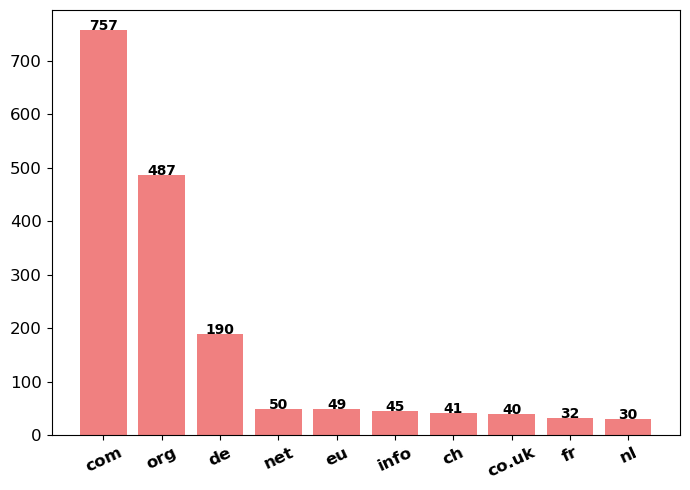

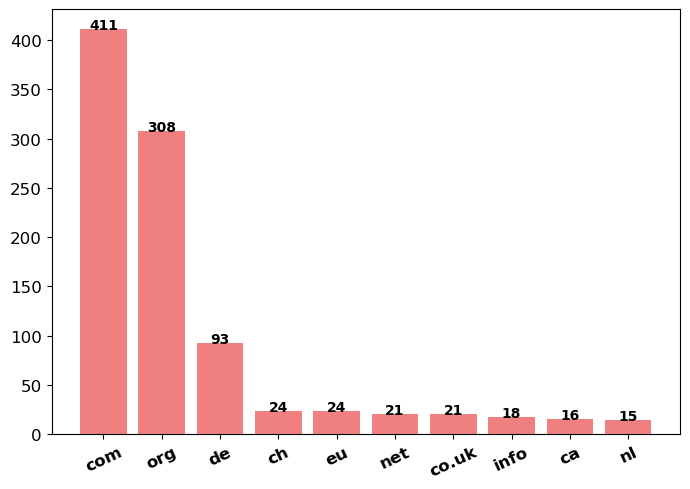

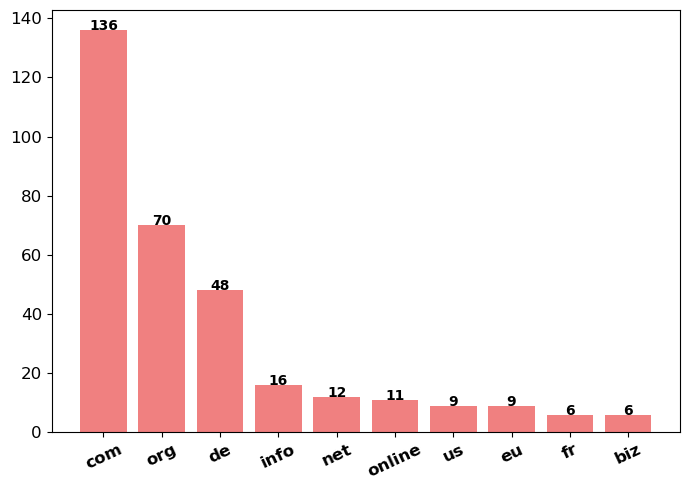

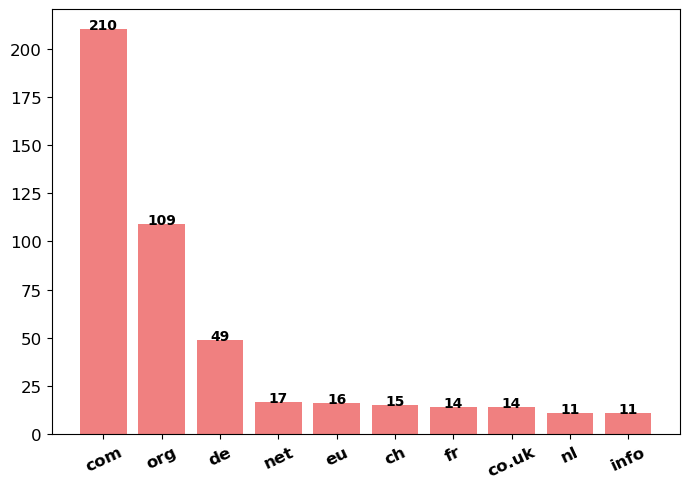

In [88]:
plot_categories_and_counts(all_tld)
plot_categories_and_counts(C_1_tld)
plot_categories_and_counts(C_2_tld)
plot_categories_and_counts(C_3_tld)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

def plot_top_10_tlds(cluster_1, cluster_2, cluster_3):
    
  
    all_tlds = list(cluster_1.keys()) + list(cluster_2.keys()) + list(cluster_3.keys())
    top_10_tlds = [tld for tld, _ in Counter(all_tlds).most_common(10)]

   
    data = {
        'TLD': top_10_tlds,
        'Cluster_1': [cluster_1.get(tld, 0) for tld in top_10_tlds],
        'Cluster_2': [cluster_2.get(tld, 0) for tld in top_10_tlds],
        'Cluster_3': [cluster_3.get(tld, 0) for tld in top_10_tlds]
    }

    
    df = pd.DataFrame(data)

   
    plt.figure(figsize=(6, 4))
    bar_width = 0.25
    x = range(len(top_10_tlds))

    plt.bar(x, df['Cluster_1'], width=bar_width, color='lightgreen', label='Cluster 1')
    plt.bar([i + bar_width for i in x], df['Cluster_2'], width=bar_width, color='lightcoral', label='Cluster 2')
    plt.bar([i + 2 * bar_width for i in x], df['Cluster_3'], width=bar_width, color='lightblue', label='Cluster 3')

    
    plt.xlabel('TLD')
    plt.ylabel('Count')
    plt.title('Top 10 TLDs by Cluster')
    plt.xticks([i + bar_width for i in x], top_10_tlds, rotation=45)
    plt.legend()

    
    plt.tight_layout()
    plt.show()

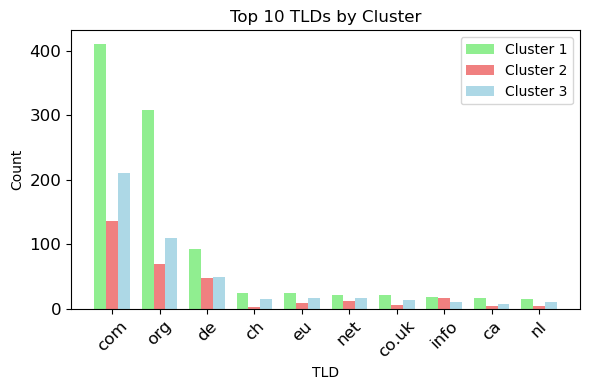

In [104]:
plot_top_10_tlds(C_1_tld, C_2_tld, C_3_tld)

In [94]:
print(list(data_[data_['Majority Voting Label']==2]['Searched_URL']))

['https://www.4myukraine.com', 'https://www.4ukraine.co', 'https://www.4ukraine.cz', 'https://www.4ukraine.eu', 'https://www.absolutejobsforukraine.be', 'https://www.act-for-ukraine.co', 'https://www.action4ukraine.org', 'https://www.action-ukraine.com', 'https://www.actionwithukraine.net', 'https://www.aheartforukraine.com', 'https://www.aideukraine.fr', 'https://www.aidforukraine.co.uk', 'https://www.aidukrainedirect.com', 'https://www.aidukrainedirect.org', 'https://www.aidukrainedirect.uk', 'https://www.aidukrainiansintheeast.org', 'https://www.airwell-ukraine.com', 'https://www.aktuelles-ukraine.de', 'https://www.alma-ukraine.com', 'https://www.ambulance2ukraine.blog', 'https://www.americaforukraine.com', 'https://www.americaforukraine.org', 'https://www.americanukrainian.net', 'https://www.americanukrainian.org', 'https://www.amkaukraine.com', 'https://www.amsterdam4ukraine.com', 'https://www.amsterdamcooksforukraine.nl', 'https://www.angels4ukraine.eu', 'https://www.ankommenausd

In [124]:
#single page website deep analysis
single_page_c_1 = data_[(data_['Majority Voting Label']==0) & (data_['Unique_Internal_Page_Link_Cnt']==1)]
single_page_c_2 = data_[(data_['Majority Voting Label']==1) & (data_['Unique_Internal_Page_Link_Cnt']==1)]
single_page_c_3 = data_[(data_['Majority Voting Label']==2) & (data_['Unique_Internal_Page_Link_Cnt']==1)]
print(len(single_page_c_1),len(single_page_c_2),len(single_page_c_3))

152 352 174


In [125]:
single_page_c_1 = single_page_c_1[single_page_c_1.columns[:28]]
single_page_c_2 = single_page_c_2[single_page_c_2.columns[:28]]
single_page_c_3 = single_page_c_3[single_page_c_3.columns[:28]]

In [126]:
single_page_c_3.head()

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Domain Hyphen Count,xn-- Present,Money Keyword Check,Help Keyword Check,Campaign Keyword Check,War Keyword Check,For and To Keyword Check,Number Instead of Word,Is WhoIs Registrar Available,Is SSL Certificate Retrievable
7,9.88,1,0,0,0,1,2,73.00,37.00,0.0,...,0,0,0,0,0,0,0,1,0,0
8,9.88,1,0,0,0,1,2,73.00,37.00,0.0,...,0,0,0,0,0,0,0,1,0,0
18,29.74,1,0,0,0,1,4,45.75,30.75,0.0,...,2,0,0,0,0,0,1,0,0,0
23,4.44,1,0,0,0,1,1,41.00,0.00,0.0,...,1,0,0,0,0,0,0,0,0,0
68,7.52,0,0,0,0,1,1,39.00,0.00,0.0,...,0,0,0,0,0,0,0,1,1,0


In [ ]:
import pandas as pd
from scipy.stats import f_oneway, kruskal

def describe_feature_differences(single_page_1, single_page_2, single_page_3, feature_cols):
   
    for df in [single_page_1, single_page_2, single_page_3]:
        for feature in feature_cols:
            df[feature] = pd.to_numeric(df[feature], errors='coerce')

   
    significant_features = []
    descriptions = []

    for feature in feature_cols:
        
        cluster_1_clean = single_page_1[feature].dropna()
        cluster_2_clean = single_page_2[feature].dropna()
        cluster_3_clean = single_page_3[feature].dropna()

        
        f_stat, p_value = f_oneway(cluster_1_clean, cluster_2_clean, cluster_3_clean)
        if p_value < 0.05: 
            significant_features.append(feature)
           
            mean_1 = cluster_1_clean.mean()
            mean_2 = cluster_2_clean.mean()
            mean_3 = cluster_3_clean.mean()
            std_1 = cluster_1_clean.std()
            std_2 = cluster_2_clean.std()
            std_3 = cluster_3_clean.std()

           
            description = (
                f"Feature '{feature}' is significantly different across clusters (p-value = {p_value:.4f}).\n"
                f"- Cluster 1: Mean = {mean_1:.2f}, Std = {std_1:.2f}\n"
                f"- Cluster 2: Mean = {mean_2:.2f}, Std = {std_2:.2f}\n"
                f"- Cluster 3: Mean = {mean_3:.2f}, Std = {std_3:.2f}\n"
                f"This suggests that '{feature}' plays a role in differentiating single-page websites across clusters.\n"
            )
            descriptions.append(description)

 
    if not significant_features:
        print("No significant features found for clustering single-page websites.")
    else:
       
        print("\n".join(descriptions))

In [135]:
feature_cols = single_page_c_1.columns
describe_feature_differences(single_page_c_1, single_page_c_2, single_page_c_3, feature_cols)

Feature 'Landing_Page_Size_In_KB' is significantly different across clusters (p-value = 0.0000).
- Cluster 1: Mean = 288.55, Std = 316.93
- Cluster 2: Mean = 1.59, Std = 3.14
- Cluster 3: Mean = 17.43, Std = 19.43
This suggests that 'Landing_Page_Size_In_KB' plays a role in differentiating single-page websites across clusters.

Feature 'Same Landing Domain' is significantly different across clusters (p-value = 0.0000).
- Cluster 1: Mean = 0.66, Std = 0.47
- Cluster 2: Mean = 0.98, Std = 0.14
- Cluster 3: Mean = 0.95, Std = 0.21
This suggests that 'Same Landing Domain' plays a role in differentiating single-page websites across clusters.

Feature 'Has Bank Related Keywords' is significantly different across clusters (p-value = 0.0000).
- Cluster 1: Mean = 0.12, Std = 0.32
- Cluster 2: Mean = 0.00, Std = 0.05
- Cluster 3: Mean = 0.11, Std = 0.31
This suggests that 'Has Bank Related Keywords' plays a role in differentiating single-page websites across clusters.

Feature 'Has Crypto Relate

C:\Users\mmia43\AppData\Local\Temp\ipykernel_25076\1944087700.py:30: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(cluster_1_clean, cluster_2_clean, cluster_3_clean)


In [137]:
def within_cluster_analysis_bin_feature(df,cluster_name):
  
  # #for binary column entries
  has_cheap_tld = df['Is Cheapest TLD'].to_list()
  has_cc = df['Is Combined TLD'].to_list()
  xn = df['xn-- Present'].to_list()
  money = df['Money Keyword Check'].to_list()
  help = df['Help Keyword Check'].to_list()
  camp = df['Campaign Keyword Check'].to_list()
  war = df['War Keyword Check'].to_list()
  for_to = df['For and To Keyword Check'].to_list()
  _4_2 = df['Number Instead of Word'].to_list()
  ssl = df['Is SSL Certificate Retrievable'].to_list()
  who = df['Is WhoIs Registrar Available'].to_list()

  column = ['Is Cheapest TLD', 'Is Combined TLD', 'Is xn-- Present','Money Keyword Check','Help Keyword Check',
            'Campaign Keyword Check','War Keyword Check','For and To Keyword Check','Number Instead of Word','Is SSL Certificate Retrievable','Is WhoIs Registrar Available']
  count_val = {
    'Ones': np.array([has_cheap_tld.count(1),has_cc.count(1),xn.count(1),money.count(1),help.count(1),camp.count(1),war.count(1),for_to.count(1),_4_2.count(1),ssl.count(1),who.count(1)]),
    'Zeroes': np.array([has_cheap_tld.count(0),has_cc.count(0),xn.count(0),money.count(0),help.count(0),camp.count(0),war.count(0),for_to.count(0),_4_2.count(0),ssl.count(0),who.count(0)]),
  }
  width = 0.8  # the width of the bars: can also be len(x) sequence


  fig, ax = plt.subplots(figsize=(36, 12))
  bottom = np.zeros(len(column))

  for label, val in count_val.items():
    p = ax.bar(column, val, width, label=label, bottom=bottom)
    bottom += val

    ax.bar_label(p, label_type='center')

  ax.set_title('Analysis for the binary Features for '+ cluster_name)
  ax.legend()

  plt.show()

In [138]:
def within_cluster_analysis_num_feature(df,cluster_name):
  # for numerical column entries
  column = ["Spamhaus TLD Rank", "Domain Letter Count", "Domain Digit Rate", "Domain Hyphen Count"]
  stats = {
    'Mean': np.round((st.mean(df['Spamhaus TLD Rank']), st.mean(df['Domain Letter Count']), st.mean(df['Domain Digit Rate']), st.mean(df["Domain Hyphen Count"])),2),
    'Median': np.round((st.median(df['Spamhaus TLD Rank']), st.median(df['Domain Letter Count']), st.median(df['Domain Digit Rate']), st.median(df["Domain Hyphen Count"])),2),
    'Mode': np.round((st.mode(df['Spamhaus TLD Rank']), st.mode(df['Domain Letter Count']), st.mode(df['Domain Digit Rate']), st.mode(df["Domain Hyphen Count"])),2),
    'STD': np.round((st.stdev(df['Spamhaus TLD Rank']), st.stdev(df['Domain Letter Count']), st.stdev(df['Domain Digit Rate']), st.stdev(df["Domain Hyphen Count"])),2),
    'MAX':np.round((max(df['Spamhaus TLD Rank']), max(df['Domain Letter Count']), max(df['Domain Digit Rate']), max(df["Domain Hyphen Count"])),2),
    'MIN':np.round((min(df['Spamhaus TLD Rank']), min(df['Domain Letter Count']), min(df['Domain Digit Rate']), min(df["Domain Hyphen Count"])),2)
  }

  x = np.arange(len(column))  # the label locations
  width = 0.15  # the width of the bars
  multiplier = 0

  fig, ax = plt.subplots(layout='constrained',figsize=(20,8))

  for attribute, measurement in stats.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=5)
    multiplier += 1

  # Add some text for labels, title and custom x-axis tick labels, etc.
  ax.set_ylabel('value')
  ax.set_title('Numerical Feature Analysis of '+ cluster_name)
  ax.set_xticks(x + width, column)
  ax.legend(loc='upper left', ncols=len(column))
  ax.set_ylim(0, 40)
  plt.show()

In [139]:
def within_cluster_analysis_content_bin_feature(df,cluster_name):

  # #for binary column entries
  same_landing_dom = df['Same Landing Domain'].to_list()
  has_bank_text = df['Has Bank Related Keywords'].to_list()
  has_crypto = df['Has Crypto Related Keywords'].to_list()
  has_card = df['Has Card Related Keywords'].to_list()
  has_form = df['Has_Google_Form_External_Link'].to_list()
  has_paypal = df['Has_Paypal_External_Link'].to_list()

  column = ['Same Landing Domain', 'Has Bank Related Keywords', 'Has Crypto Related Keywords','Has Card Related Keywords','Has_Google_Form_External_Link','Has_Paypal_External_Link']
  count_val = {
    'Ones': np.array([same_landing_dom.count(1),has_bank_text.count(1),has_crypto.count(1),has_card.count(1),has_form.count(1),has_paypal.count(1)]),
    'Zeroes': np.array([same_landing_dom.count(0),has_bank_text.count(0),has_crypto.count(0),has_card.count(0),has_form.count(0),has_paypal.count(0)]),
  }

  width = 0.8  # the width of the bars: can also be len(x) sequence

  fig, ax = plt.subplots(figsize=(36, 12))
  bottom = np.zeros(len(column))

  for label, val in count_val.items():
    p = ax.bar(column, val, width, label=label, bottom=bottom)
    bottom += val

    ax.bar_label(p, label_type='center')

  ax.set_title('Analysis for the binary Features for '+ cluster_name)
  ax.legend()
  plt.show()


In [140]:
def within_cluster_analysis_num_content_feature(df,cluster_name,y_lim=700):
  # for numerical column entries
  column = ["Unique_Internal_Page_Link_Cnt", "Unique_External_Page_Link_Cnt", "Avg_External_Links_Len",
            'Stdv_External_Links_Len', 'Ratio_Shortened_URL_And_External_Links', 'Ratio_Social_Media_Links_And_External_Links']
  stats = {
    'Mean': np.round((st.mean(df['Unique_Internal_Page_Link_Cnt']), st.mean(df['Unique_External_Page_Link_Cnt']), st.mean(df["Avg_External_Links_Len"]), st.mean(df["Stdv_External_Links_Len"]), st.mean(df["Ratio_Shortened_URL_And_External_Links"]), st.mean(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'Median': np.round((st.median(df['Unique_Internal_Page_Link_Cnt']), st.median(df['Unique_External_Page_Link_Cnt']), st.median(df["Avg_External_Links_Len"]), st.median(df["Stdv_External_Links_Len"]), st.median(df["Ratio_Shortened_URL_And_External_Links"]), st.median(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'Mode': np.round((st.mode(df['Unique_Internal_Page_Link_Cnt']), st.mode(df['Unique_External_Page_Link_Cnt']), st.mode(df["Avg_External_Links_Len"]), st.mode(df["Stdv_External_Links_Len"]), st.mode(df["Ratio_Shortened_URL_And_External_Links"]), st.mode(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'STD': np.round((st.stdev(df['Unique_Internal_Page_Link_Cnt']), st.stdev(df['Unique_External_Page_Link_Cnt']), st.stdev(df["Avg_External_Links_Len"]), st.stdev(df["Stdv_External_Links_Len"]), st.stdev(df["Ratio_Shortened_URL_And_External_Links"]), st.stdev(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'MAX':np.round((max(df['Unique_Internal_Page_Link_Cnt']), max(df['Unique_External_Page_Link_Cnt']), max(df["Avg_External_Links_Len"]), max(df["Stdv_External_Links_Len"]), max(df["Ratio_Shortened_URL_And_External_Links"]), max(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'MIN':np.round((min(df['Unique_Internal_Page_Link_Cnt']), min(df['Unique_External_Page_Link_Cnt']), min(df["Avg_External_Links_Len"]), min(df["Stdv_External_Links_Len"]), min(df["Ratio_Shortened_URL_And_External_Links"]), min(df["Ratio_Social_Media_Links_And_External_Links"])),2),
  }

  x = np.arange(len(column))  # the label locations
  width = 0.15  # the width of the bars
  multiplier = 0
 

  fig, ax = plt.subplots(figsize=(20,8),layout='constrained')

  for attribute, measurement in stats.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=5)
    multiplier += 1

  # Add some text for labels, title and custom x-axis tick labels, etc.
  ax.set_ylabel('value')
  ax.set_title('Numerical Feature Analysis of '+ cluster_name)
  ax.set_xticks(x + width, column)
  ax.legend(loc='upper left', ncols=len(column))
  ax.set_ylim(0, y_lim)
  plt.show()

In [ ]:
def within_cluster_analysis_num_content2_feature(df,cluster_name,y_lim=5000):
  # for numerical column entries
  column = ["Landing_Page_Size_In_KB"]
  stats = {
    'Mean': np.round((st.mean(df['Landing_Page_Size_In_KB'])),2),
    'Median': np.round((st.median(df['Landing_Page_Size_In_KB'])),2),
    'Mode': np.round((st.mode(df['Landing_Page_Size_In_KB'])),2),
    'STD': np.round((st.stdev(df['Landing_Page_Size_In_KB'])),2),
    'MAX':np.round((max(df['Landing_Page_Size_In_KB'])),2),
    'MIN':np.round((min(df['Landing_Page_Size_In_KB'])),2),
  }

  x = np.arange(len(column))  # the label locations
  width = 0.15  # the width of the bars
  multiplier = 0
 

  fig, ax = plt.subplots(figsize=(20,8),layout='constrained')

  for attribute, measurement in stats.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=5)
    multiplier += 1

  # Add some text for labels, title and custom x-axis tick labels, etc.
  ax.set_ylabel('value')
  ax.set_title('Numerical Feature Analysis of '+ cluster_name)
  ax.set_xticks(x + width, column)
  ax.legend(loc='upper left', ncols=len(column))
  ax.set_ylim(0, y_lim)
  plt.show()

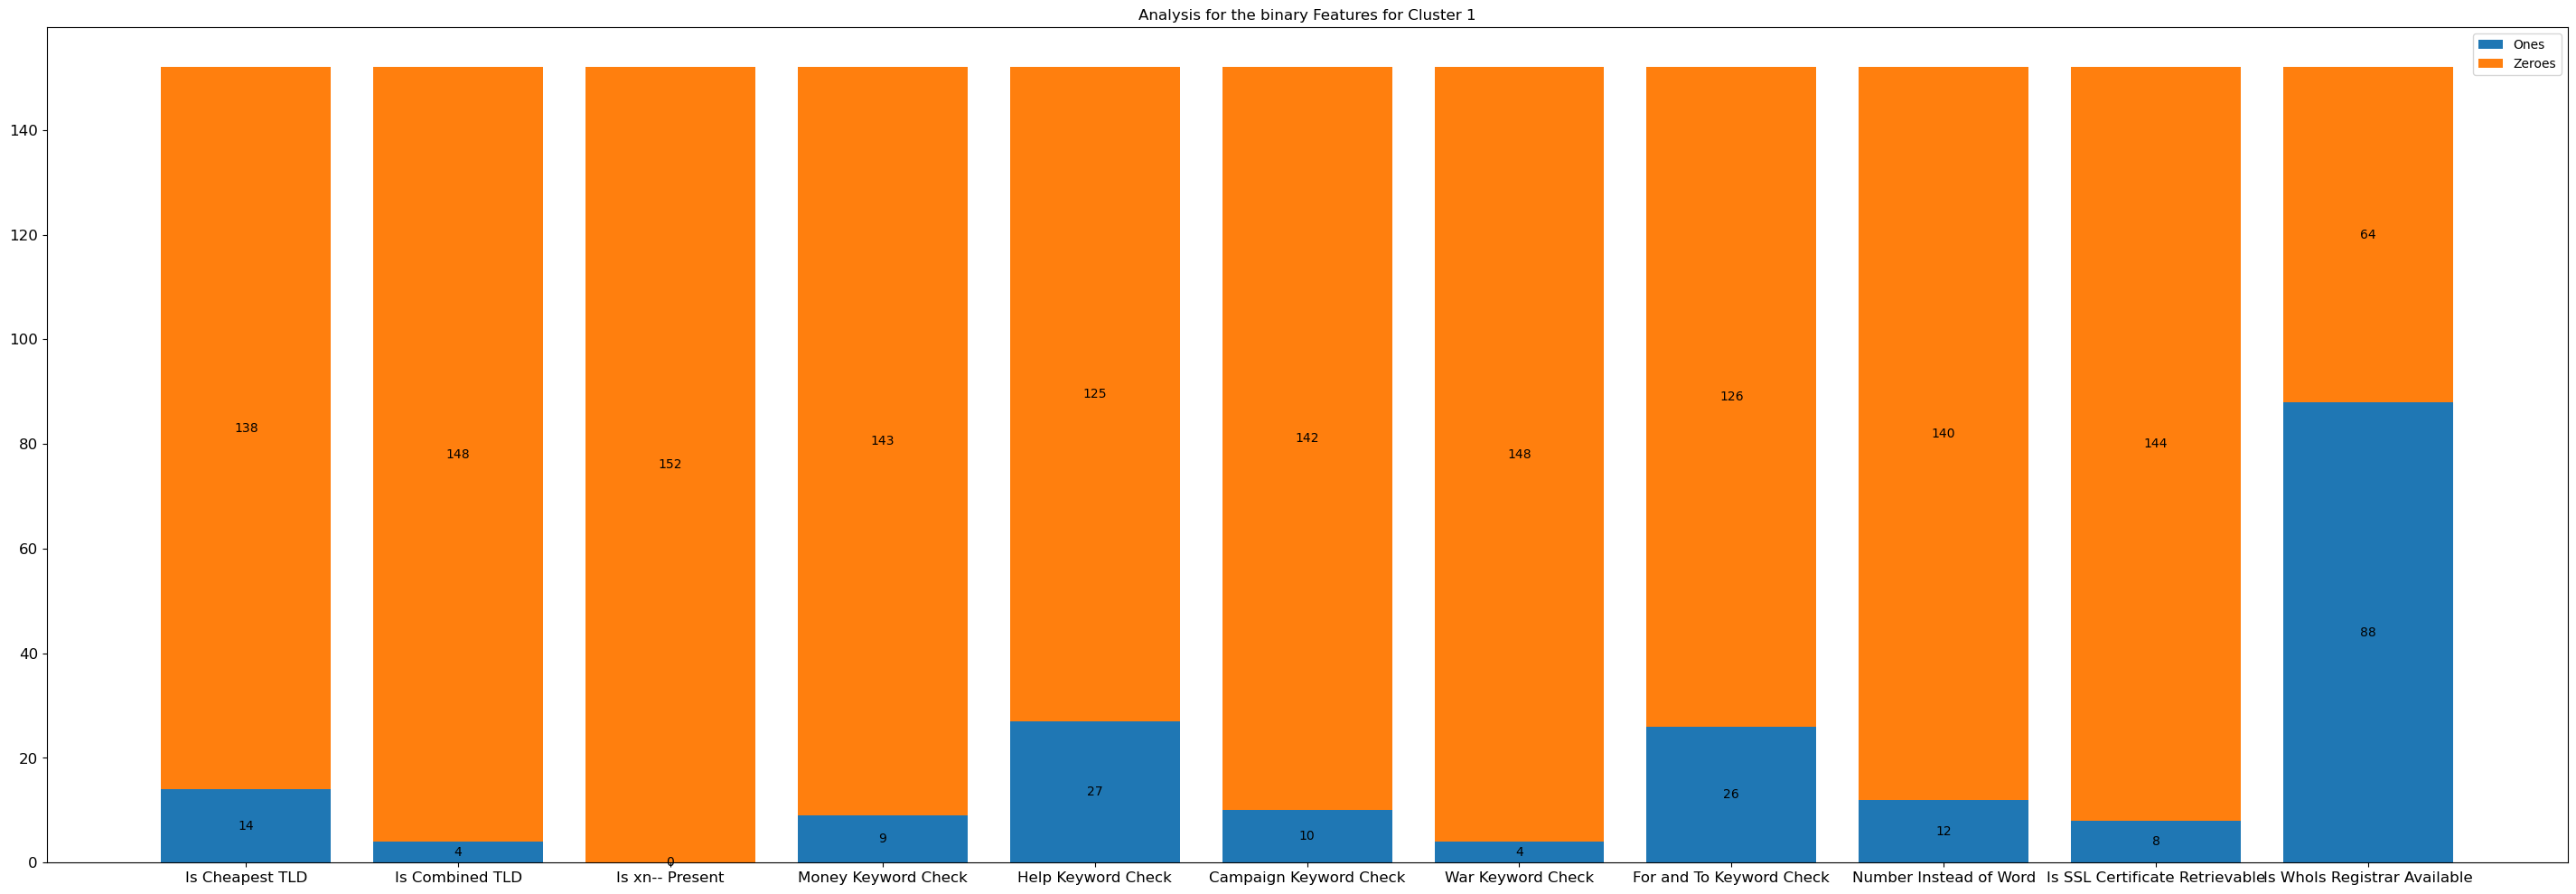

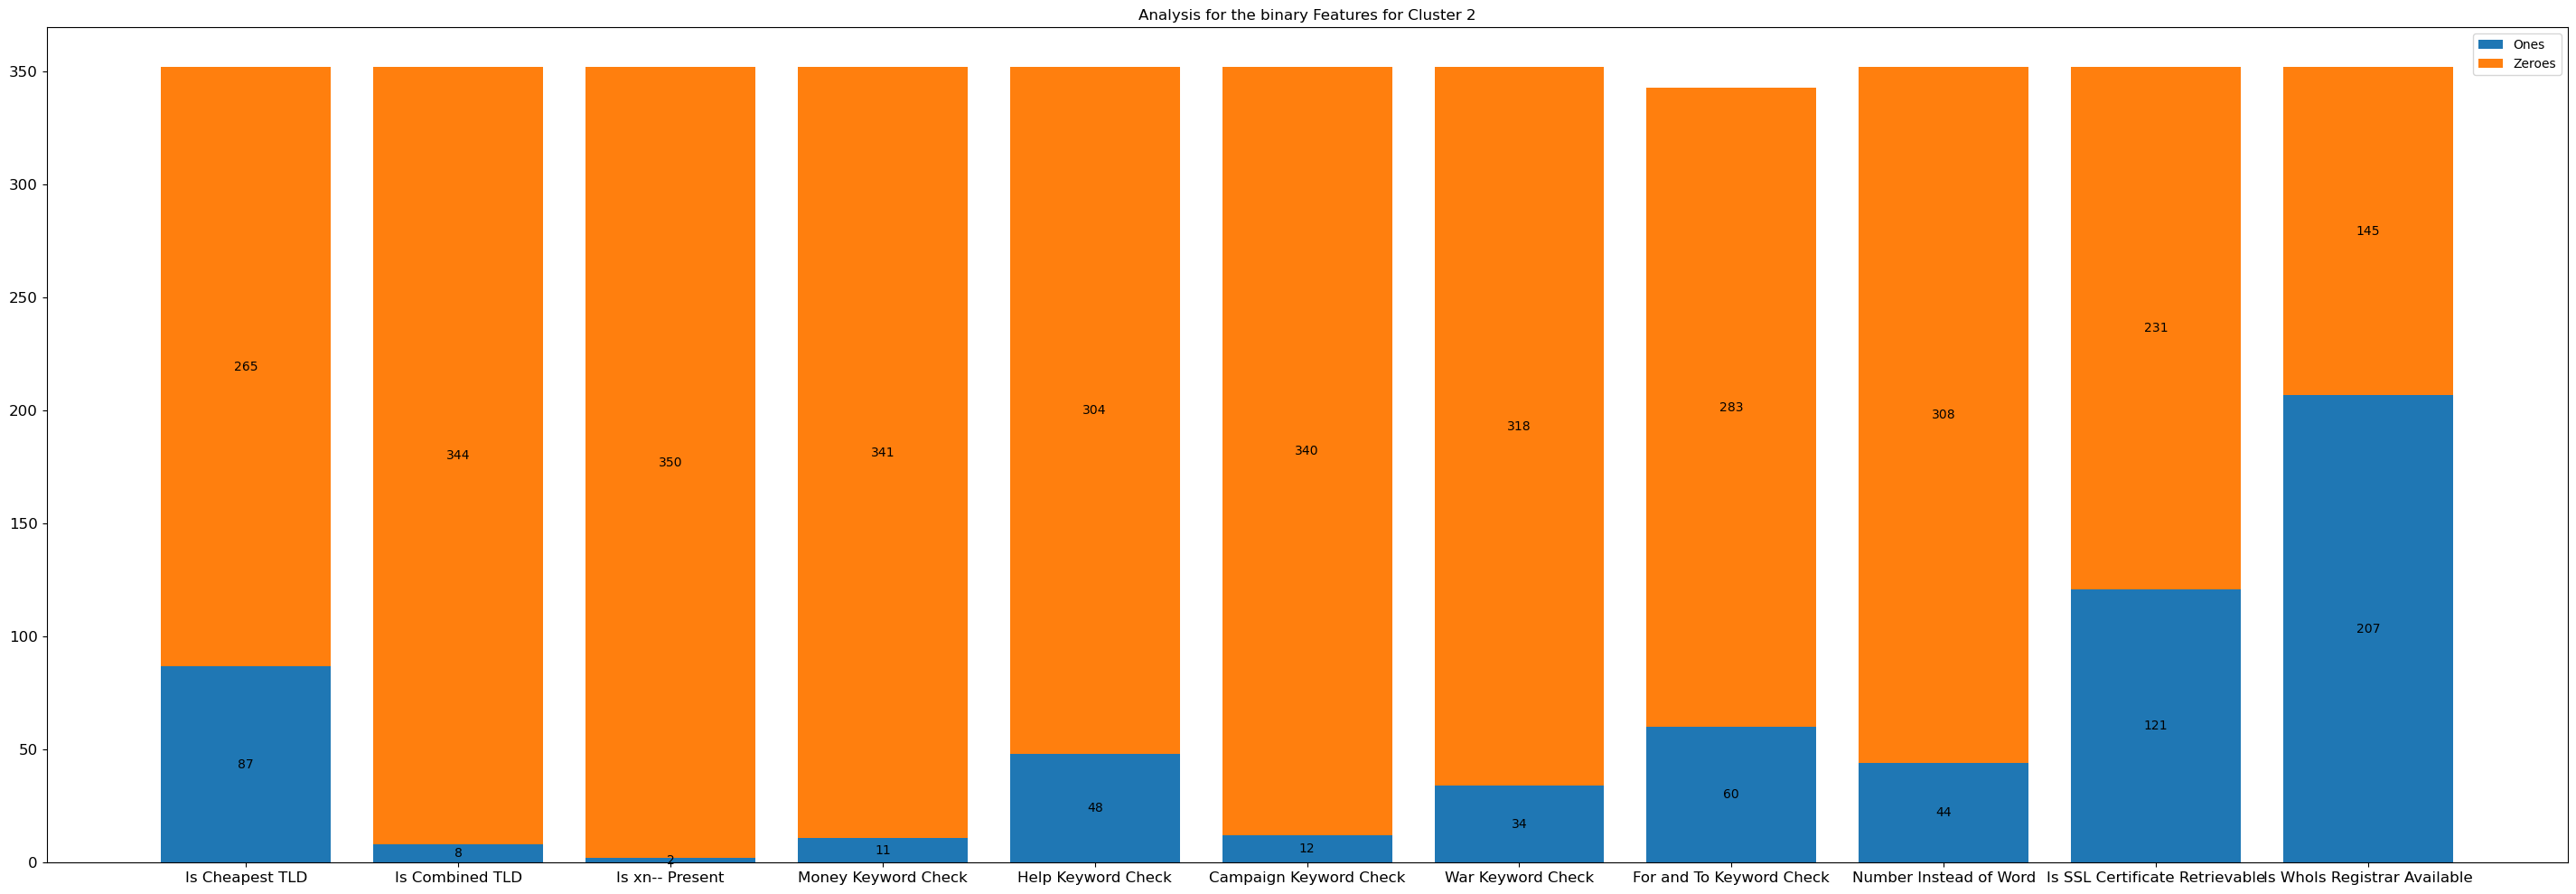

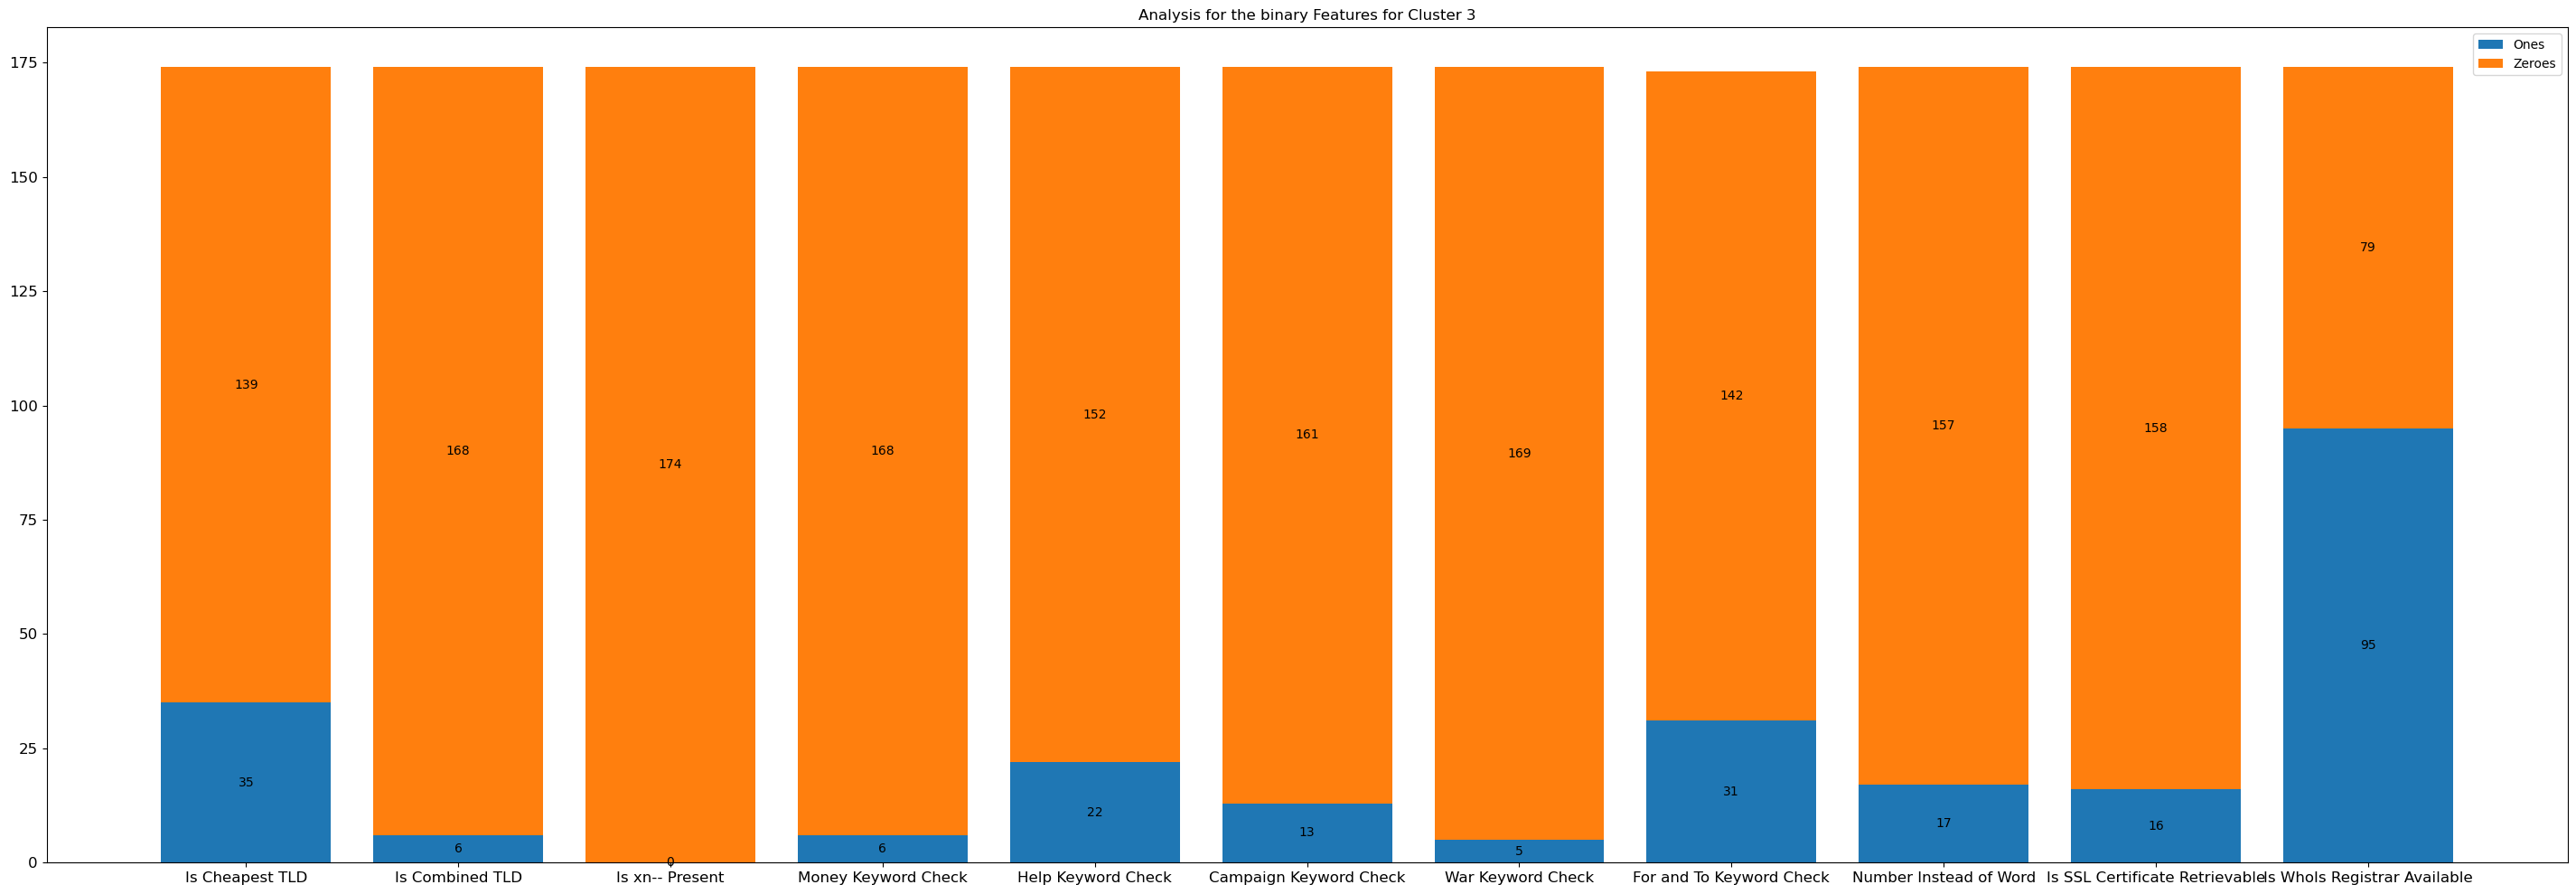

In [141]:
within_cluster_analysis_bin_feature(single_page_c_1,'Cluster 1')
within_cluster_analysis_bin_feature(single_page_c_2,'Cluster 2')
within_cluster_analysis_bin_feature(single_page_c_3,'Cluster 3')

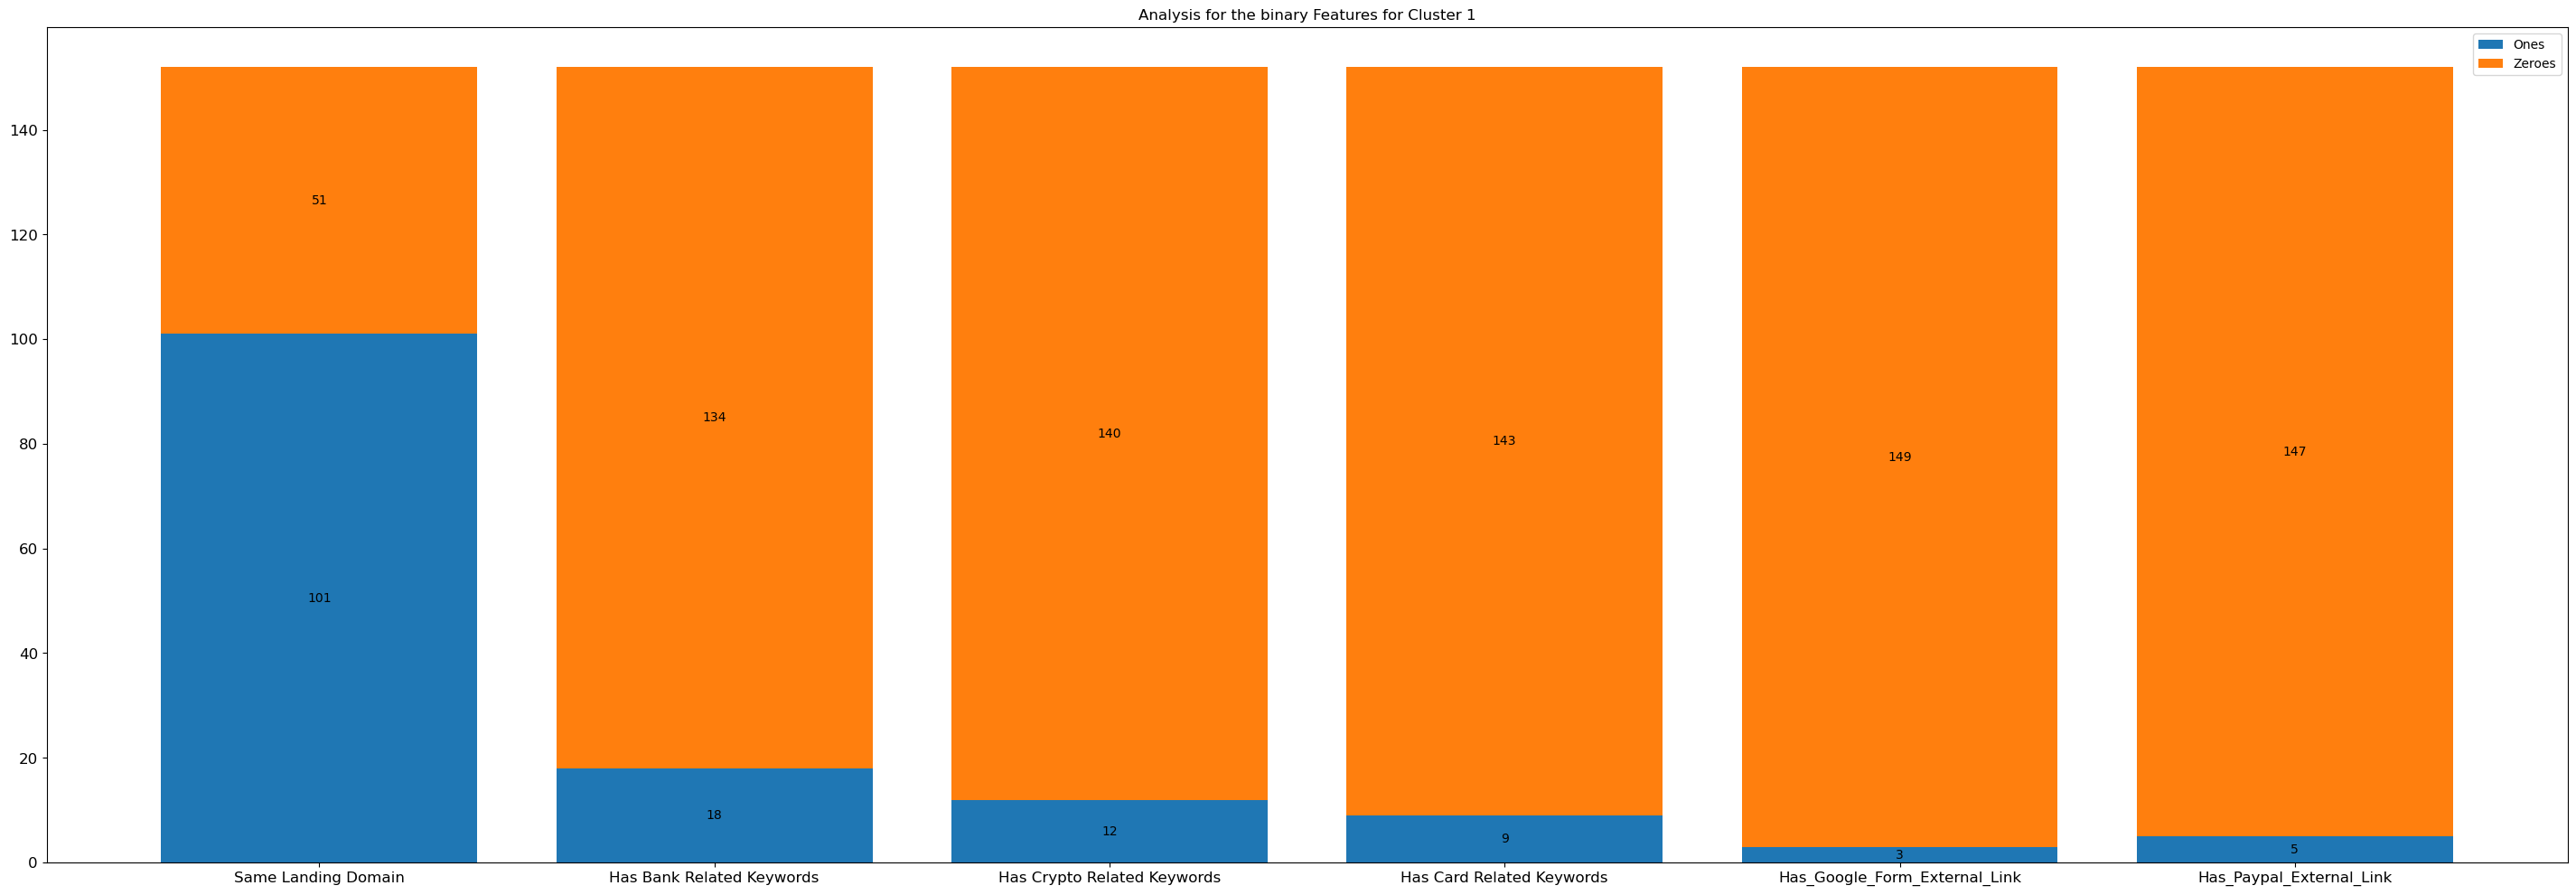

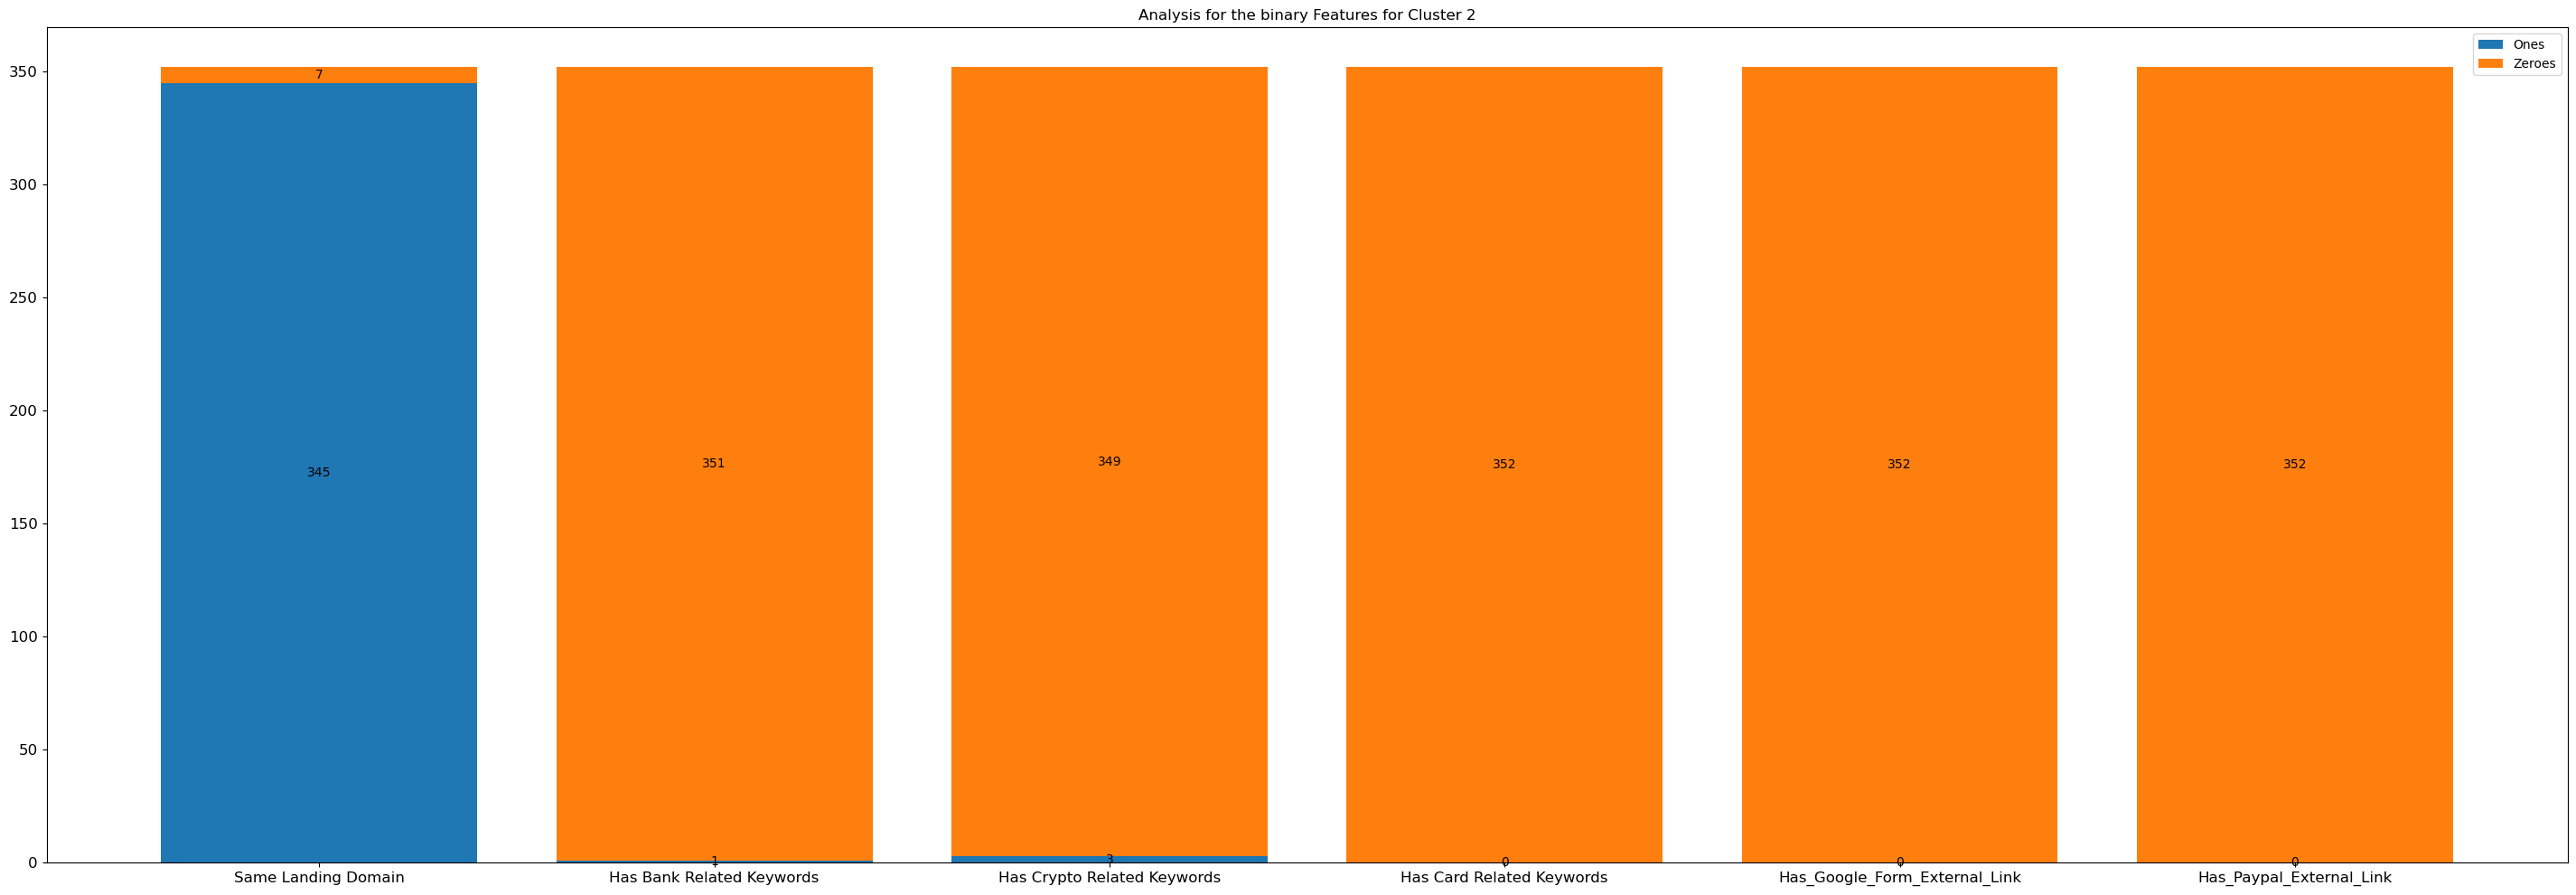

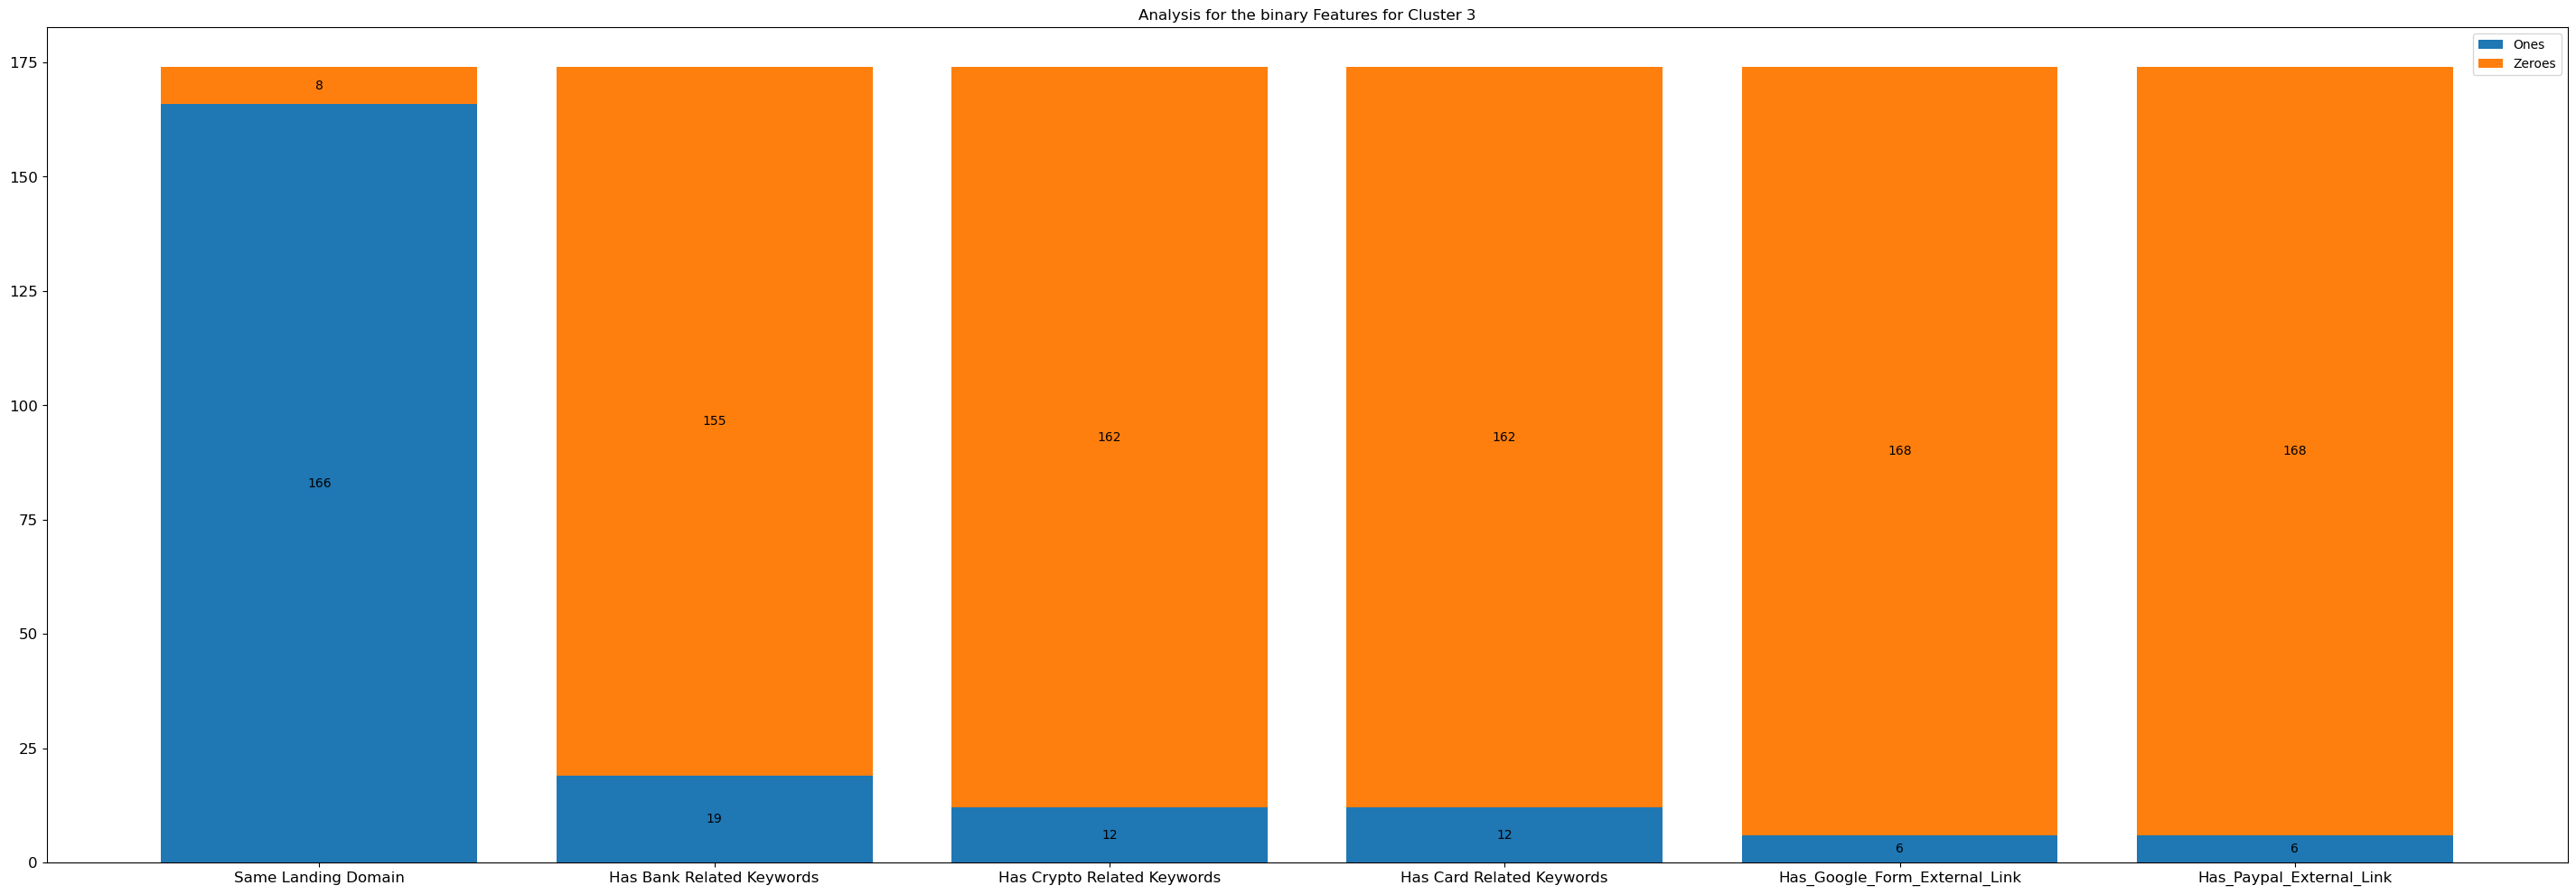

In [143]:
within_cluster_analysis_content_bin_feature(single_page_c_1,'Cluster 1')
within_cluster_analysis_content_bin_feature(single_page_c_2,'Cluster 2')
within_cluster_analysis_content_bin_feature(single_page_c_3,'Cluster 3')

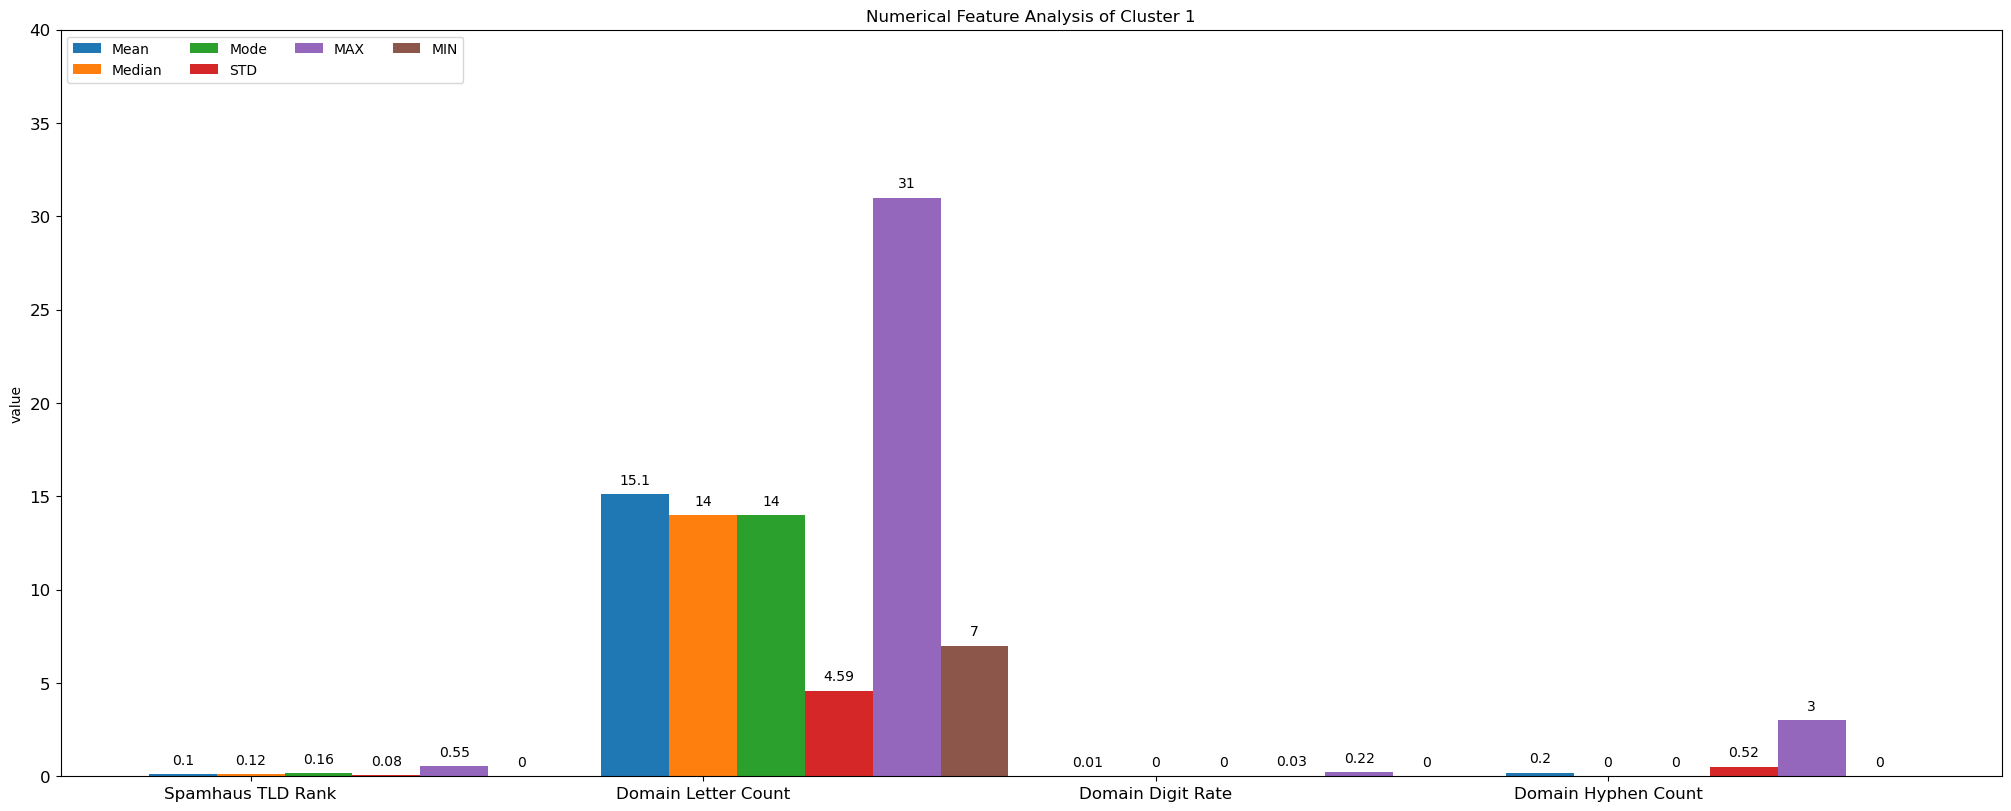

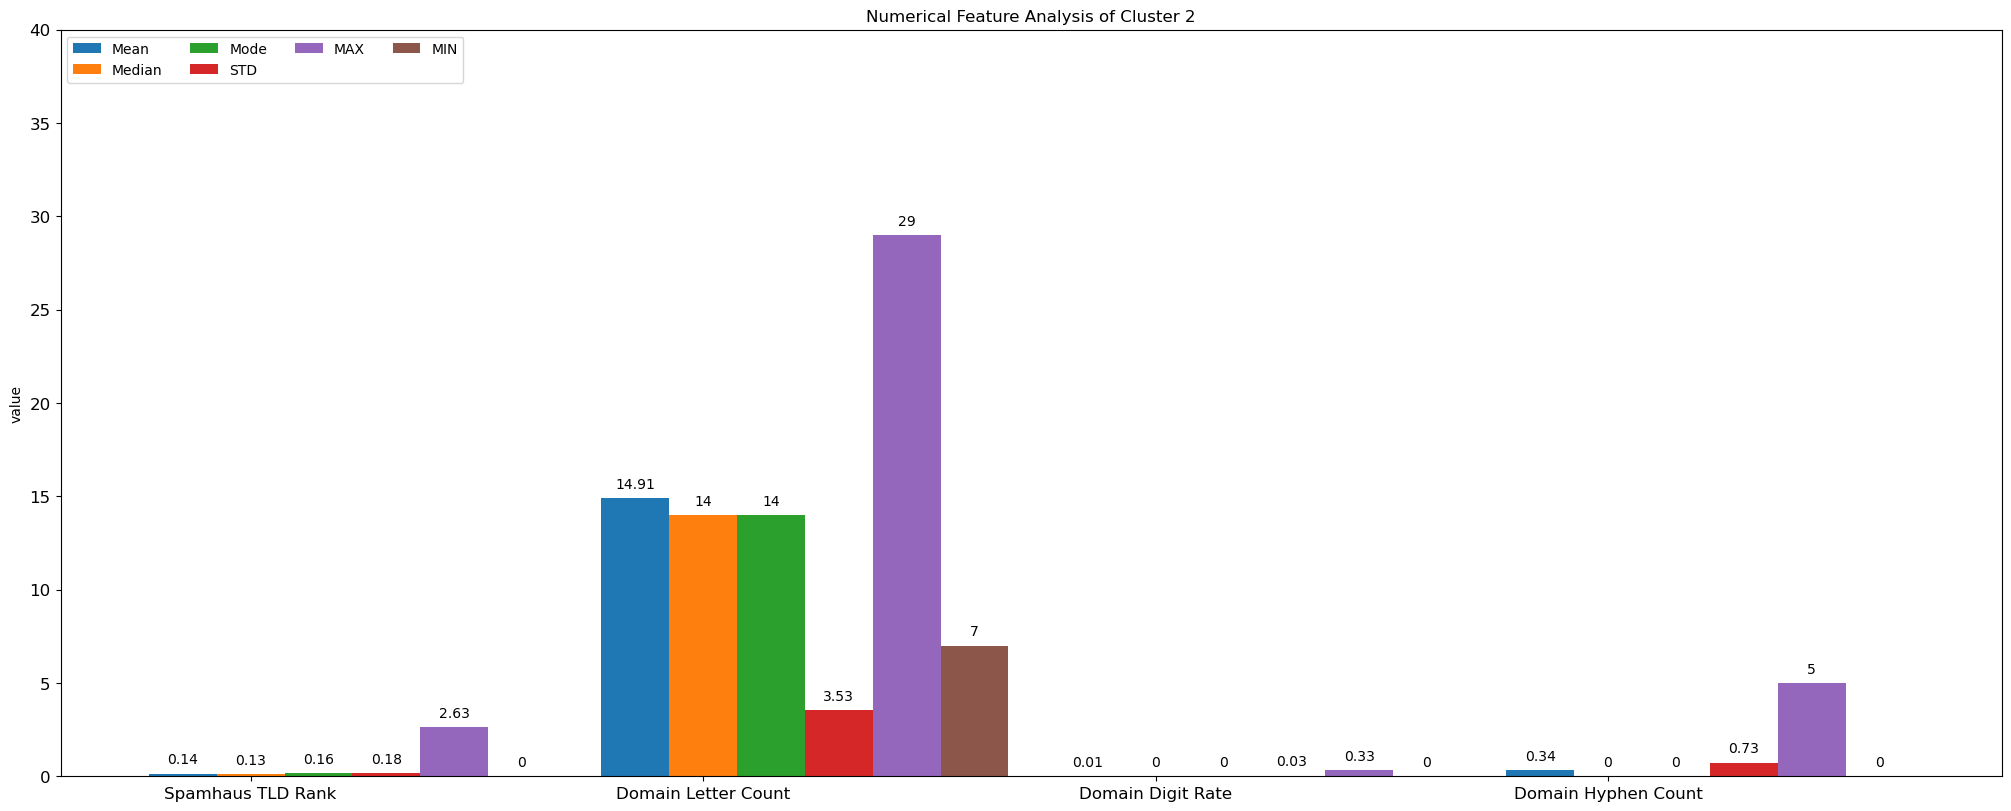

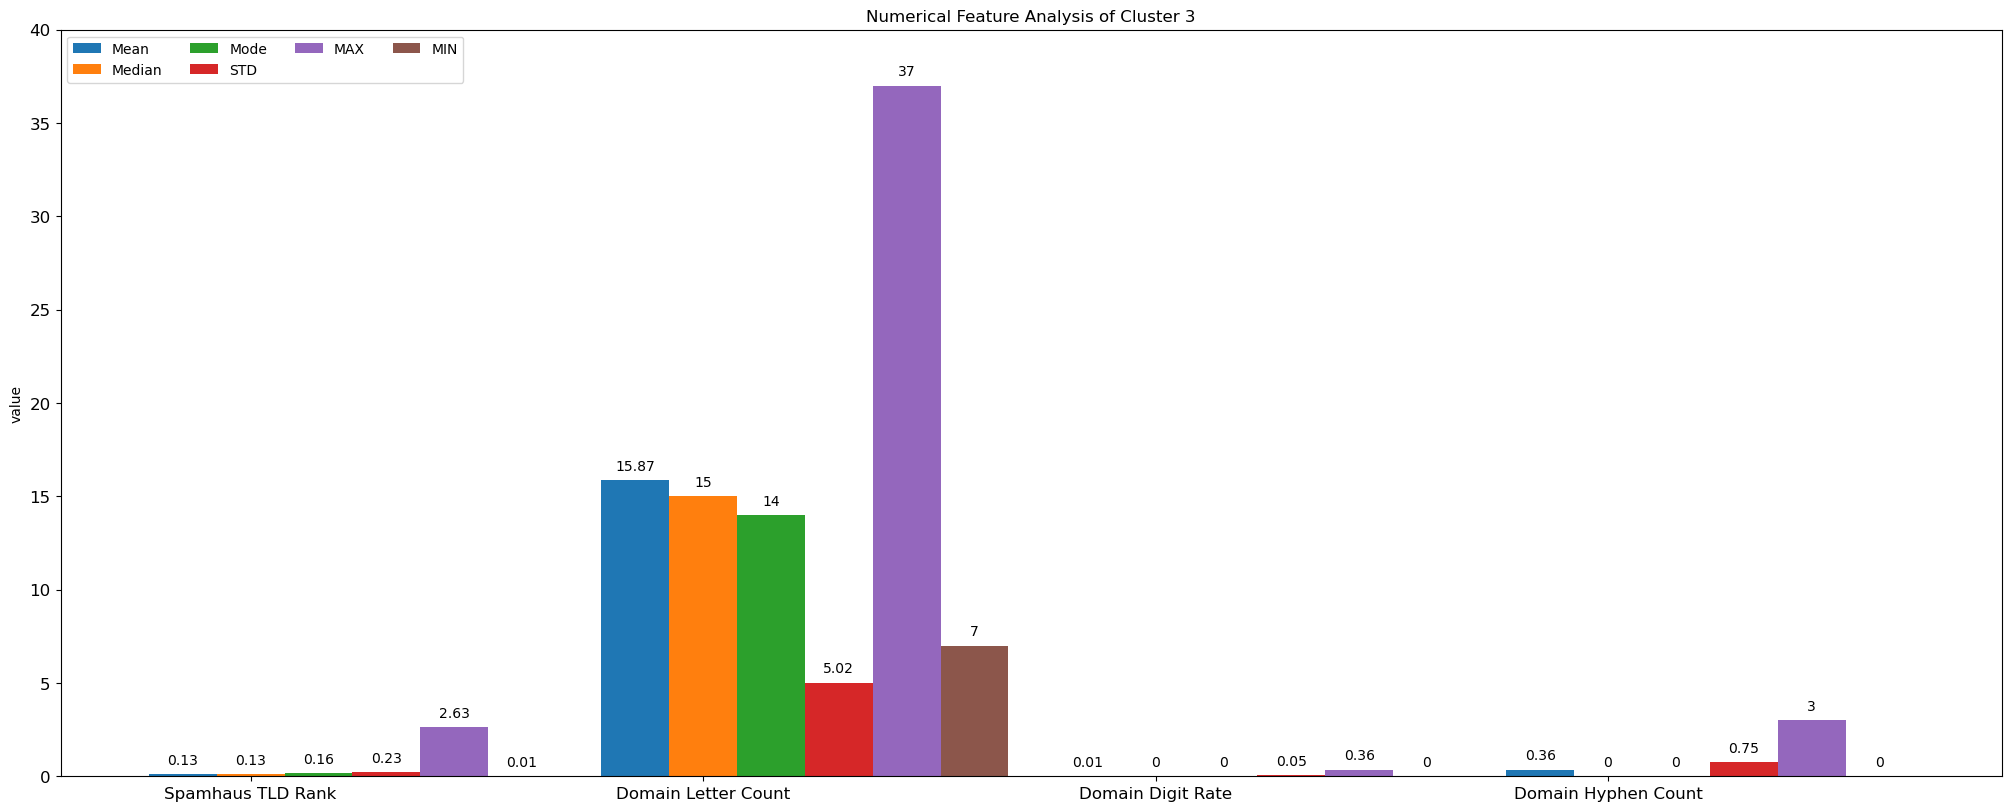

In [144]:
within_cluster_analysis_num_feature(single_page_c_1,'Cluster 1')
within_cluster_analysis_num_feature(single_page_c_2,'Cluster 2')
within_cluster_analysis_num_feature(single_page_c_3,'Cluster 3')

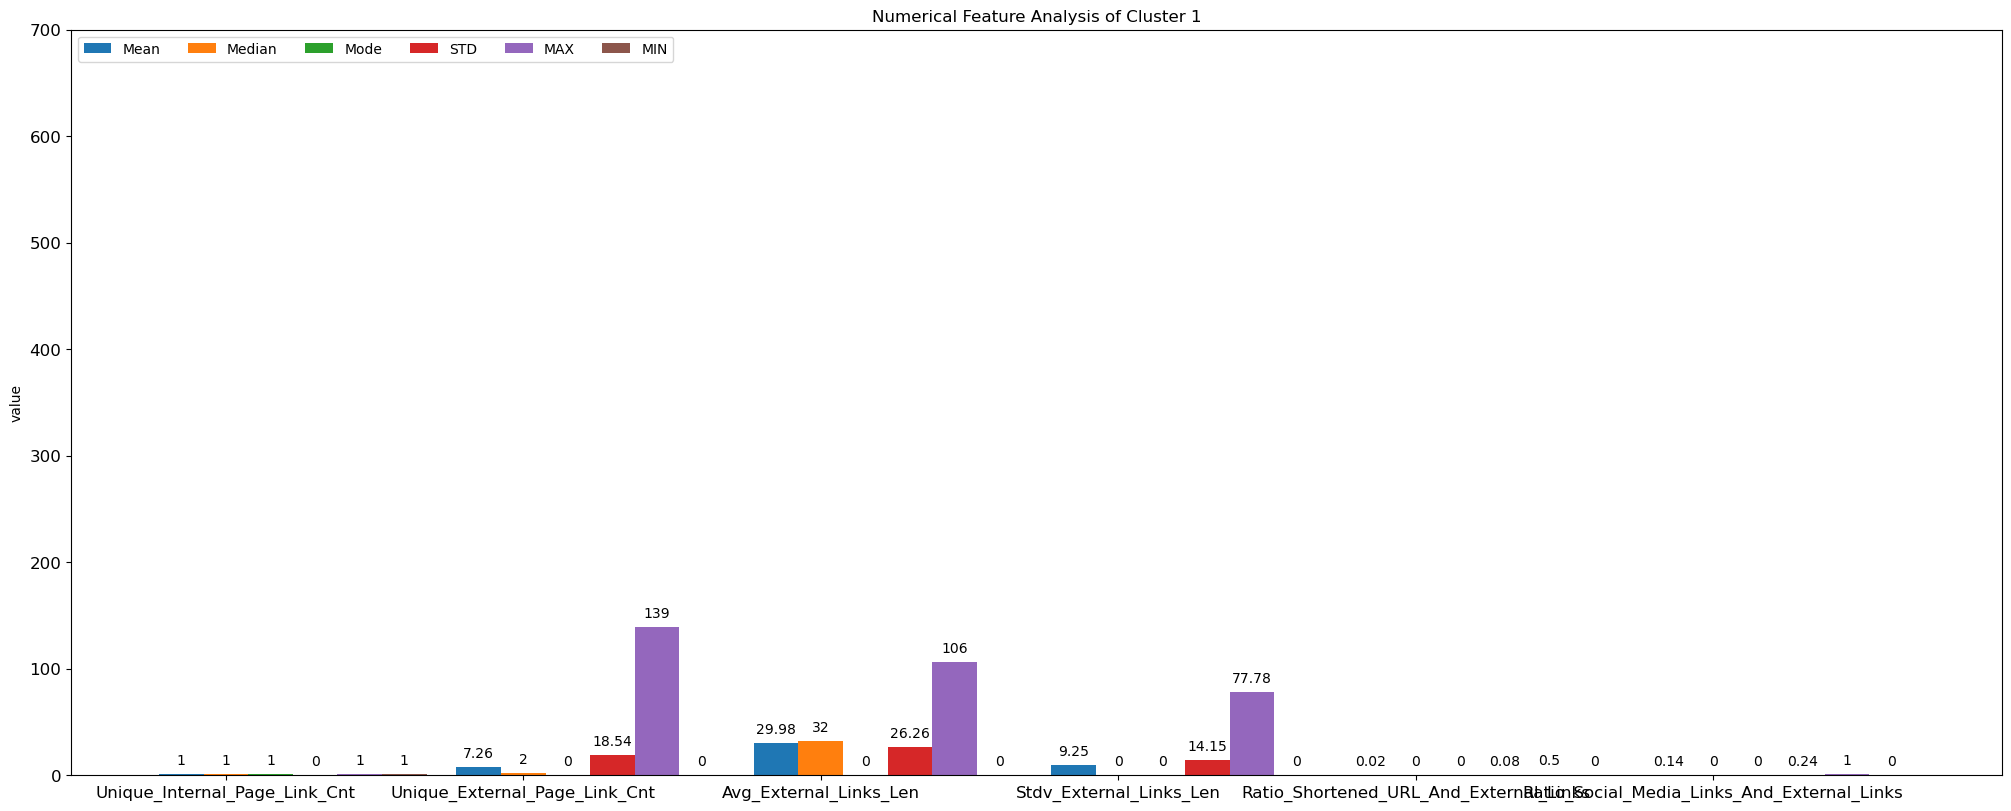

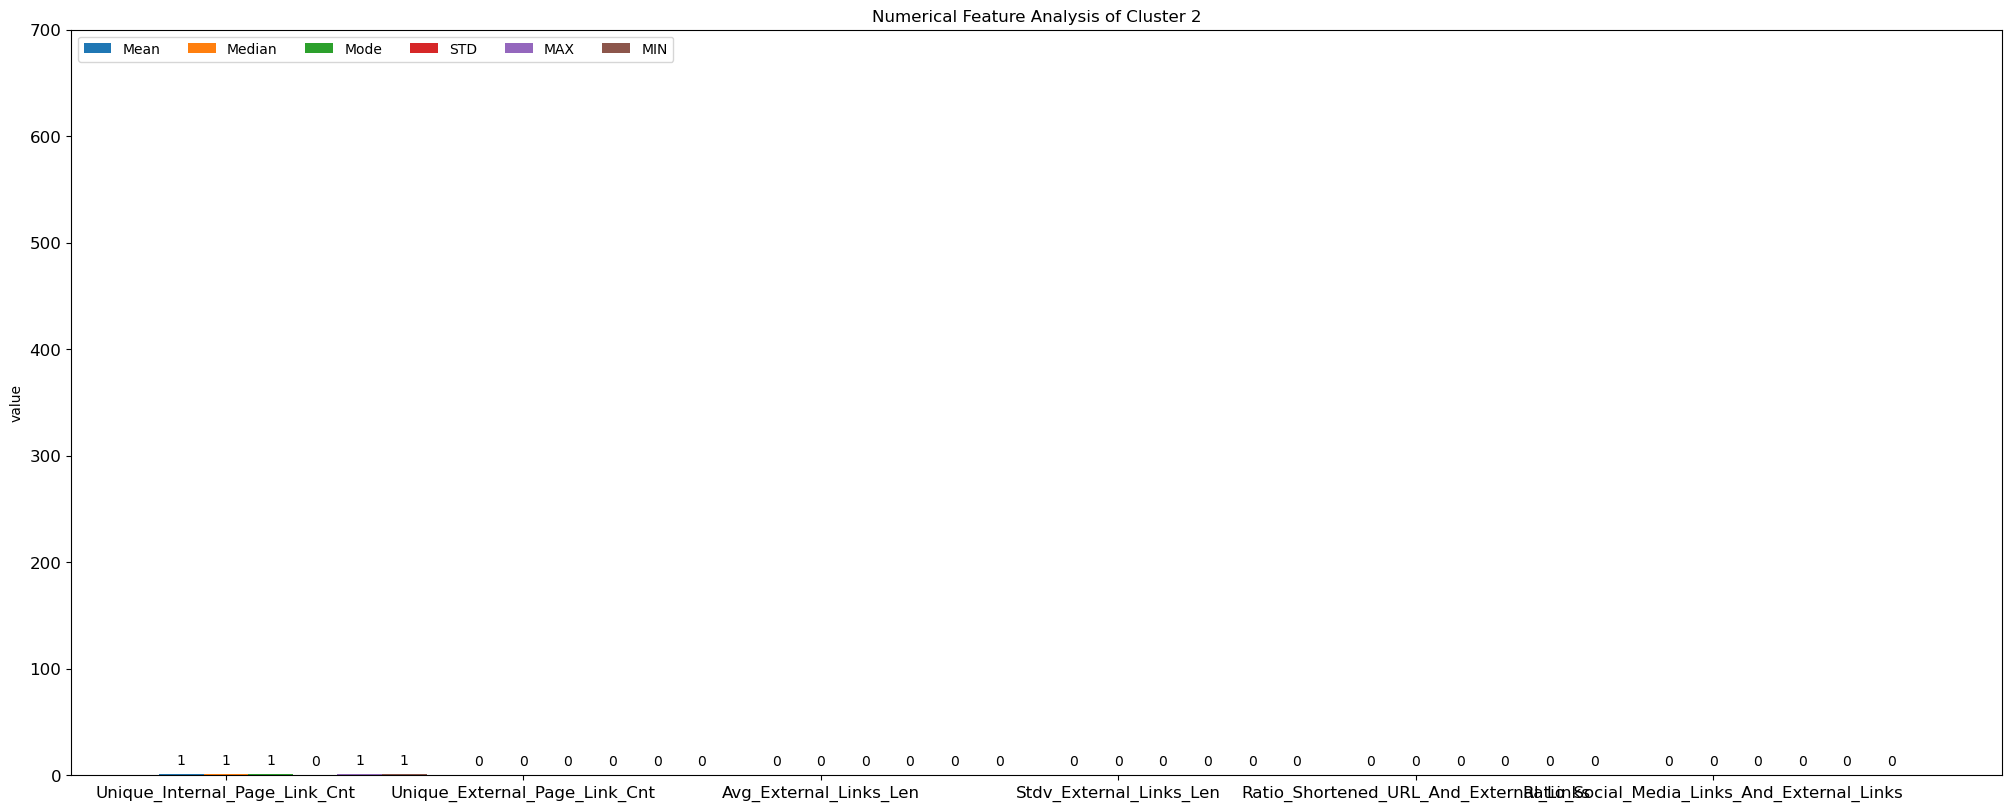

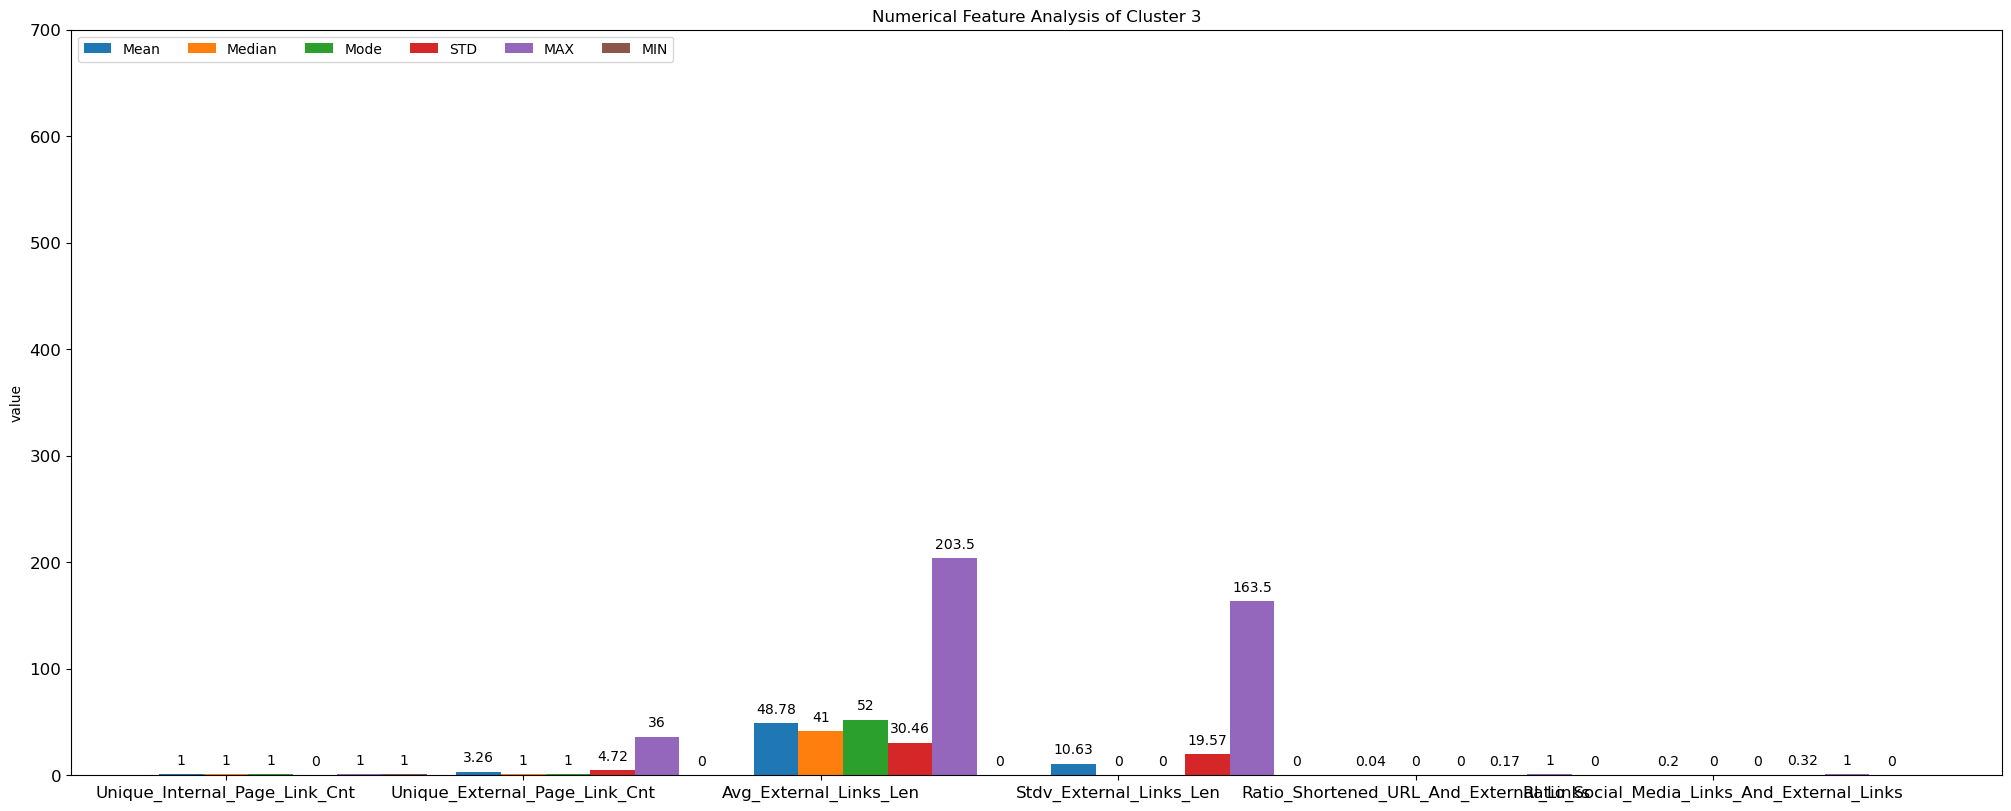

In [145]:
within_cluster_analysis_num_content_feature(single_page_c_1,'Cluster 1')
within_cluster_analysis_num_content_feature(single_page_c_2,'Cluster 2')
within_cluster_analysis_num_content_feature(single_page_c_3,'Cluster 3')

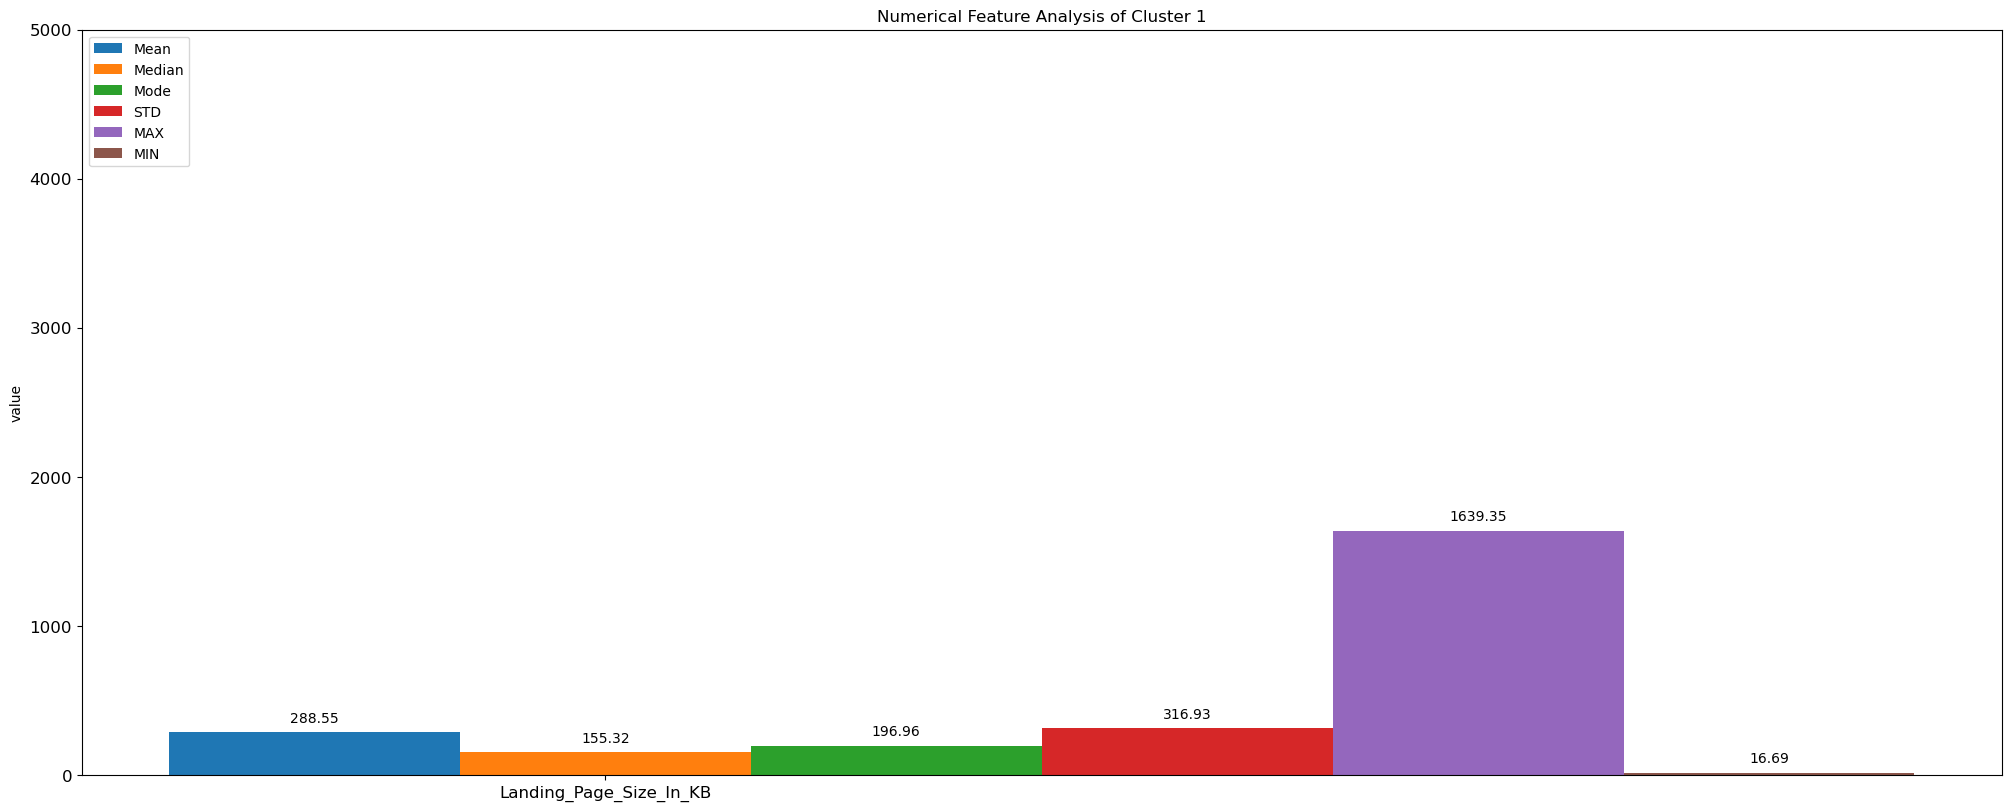

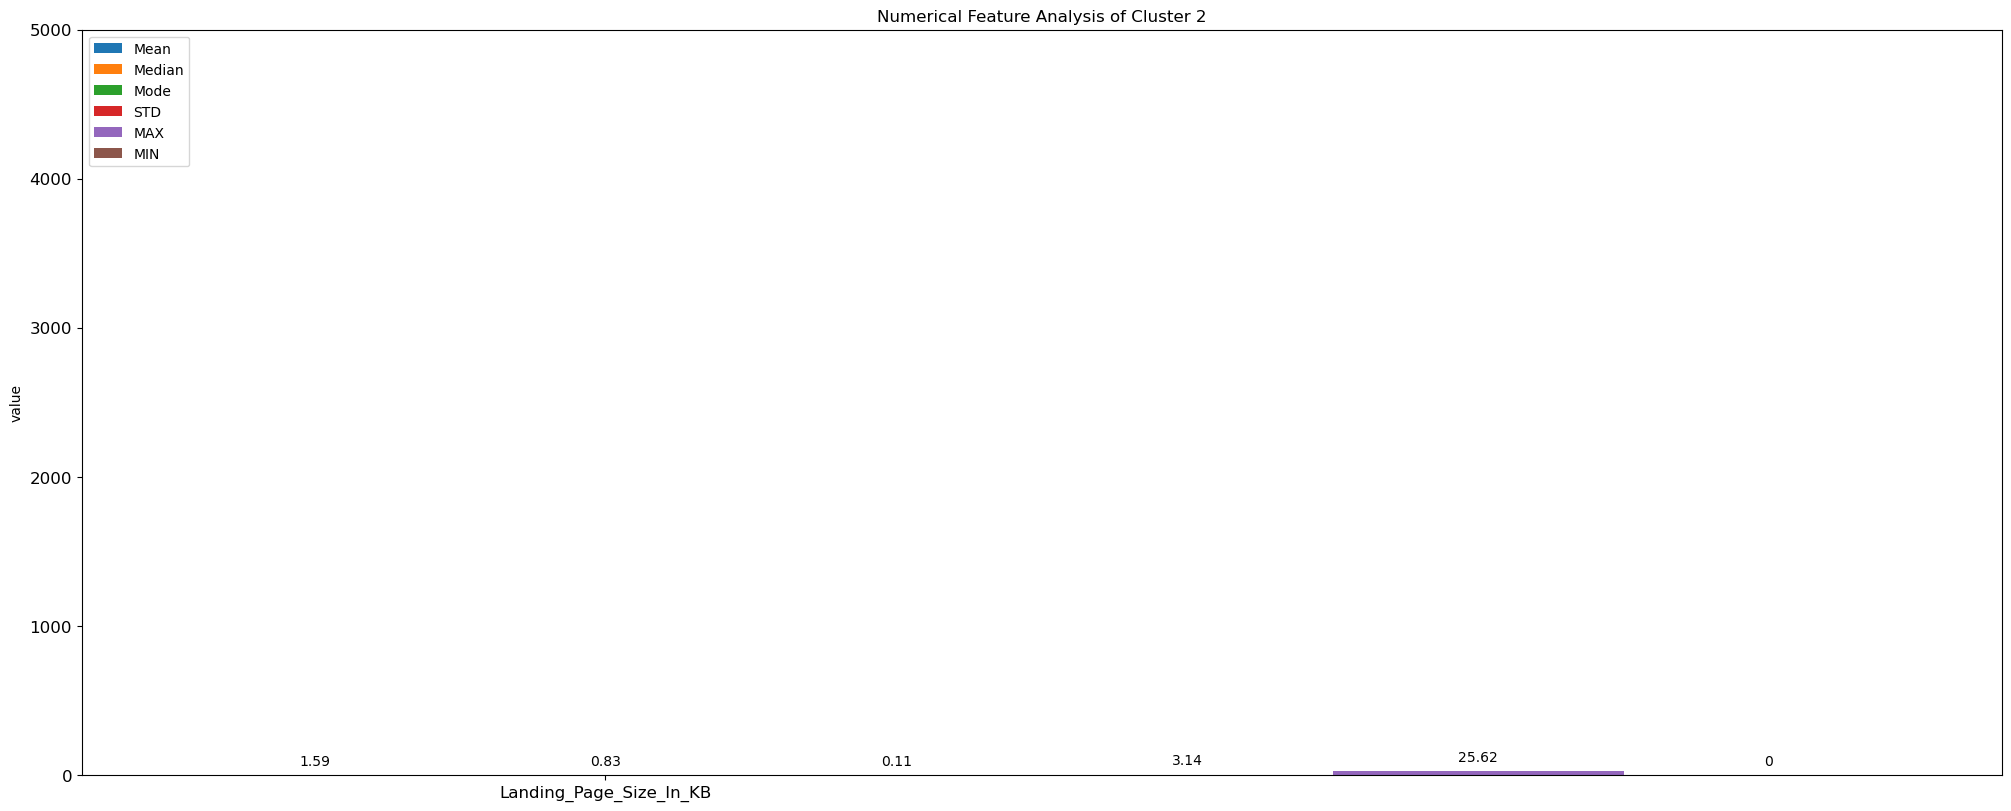

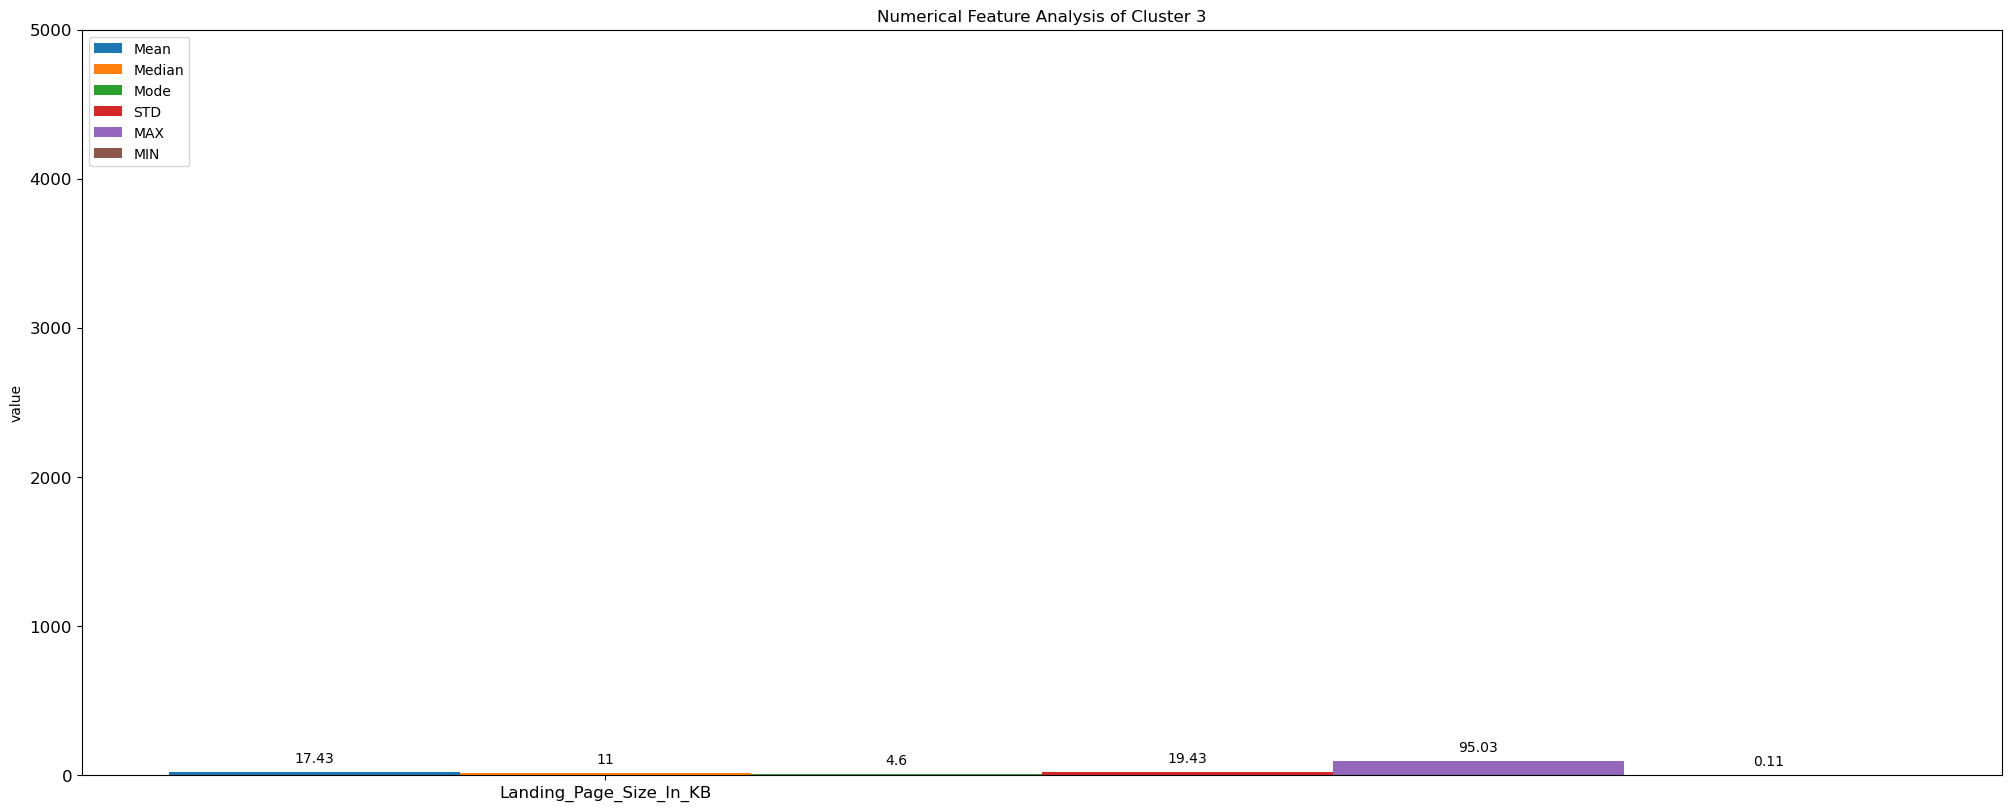

In [146]:
within_cluster_analysis_num_content2_feature(single_page_c_1,'Cluster 1')
within_cluster_analysis_num_content2_feature(single_page_c_2,'Cluster 2')
within_cluster_analysis_num_content2_feature(single_page_c_3,'Cluster 3')